In [3]:
!pip uninstall numpy -y --quiet
!pip install "numpy<2.0" --quiet
!pip uninstall scikit-surprise -y --quiet
!pip install scikit-surprise --quiet

print("✅ Installation done. NOW click: Runtime → Restart Session")
print("   Then run the next cell below (do NOT re-run this cell again).")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Graph
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score
from scipy.sparse import csr_matrix

# Matrix Factorization (SVD)
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy as surprise_accuracy

In [10]:
# STEP 1 — Data Preprocessing
# Goal: Reduce data size and improve recommendation quality
# Raw data may contain noise and inactive users

# Upload & Load the CSV files
from google.colab import files

uploaded = files.upload()

ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')

print("ratings shape:", ratings.shape)
print("movies  shape:", movies.shape)

Saving movies.csv to movies (1).csv
Saving ratings.csv to ratings (1).csv
ratings shape: (100836, 4)
movies  shape: (9742, 3)


In [11]:
# check for missing values, and see the rating scale.

print("Missing values in ratings:", ratings.isnull().sum().sum())
print("Missing values in movies :",  movies.isnull().sum().sum())
print("Unique users  :", ratings['userId'].nunique())
print("Unique movies :", ratings['movieId'].nunique())
print("Total ratings :", len(ratings))

Missing values in ratings: 0
Missing values in movies : 0
Unique users  : 610
Unique movies : 9724
Total ratings : 100836


In [12]:
#Filter Active Users & Popular Movies
# We keep only:
# Users who rated at least MIN_USER_RATINGS movies
# Movies that received at least MIN_MOVIE_RATINGS ratings

MIN_USER_RATINGS  = 50   # a user must have rated at least 50 movies
MIN_MOVIE_RATINGS = 20   # a movie must have received at least 20 ratings

# Count how many ratings each user and movie has
user_counts  = ratings['userId'].value_counts()
movie_counts = ratings['movieId'].value_counts()

# Keep only the active users and popular movies
active_users   = user_counts[user_counts  >= MIN_USER_RATINGS].index
popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index

# Filter the ratings dataframe to only include those users/movies
ratings_filtered = ratings[
    ratings['userId'].isin(active_users) &
    ratings['movieId'].isin(popular_movies)
].copy()

print(f"After filtering:")
print(f"  Users  : {ratings['userId'].nunique():>6}  →  {ratings_filtered['userId'].nunique()}")
print(f"  Movies : {ratings['movieId'].nunique():>6}  →  {ratings_filtered['movieId'].nunique()}")
print(f"  Ratings: {len(ratings):>6}  →  {len(ratings_filtered)}")

After filtering:
  Users  :    610  →  385
  Movies :   9724  →  1297
  Ratings: 100836  →  62001


In [13]:
# Convert ratings into binary values (liked = 1, not liked = 0)

LIKE_THRESHOLD = 3.5 # 3.5 and above liked, less than 3.5 not liked

ratings_filtered['liked'] = (
    ratings_filtered['rating'] >= LIKE_THRESHOLD
).astype(int)

print("Binary label distribution:")
print(ratings_filtered['liked'].value_counts())

Binary label distribution:
liked
1    40625
0    21376
Name: count, dtype: int64


In [14]:
# Keep Only Liked Interactions

liked_data = ratings_filtered[ratings_filtered['liked'] == 1].copy()

print(f"Total ratings         : {len(ratings_filtered)}")
print(f"Liked interactions (1): {len(liked_data)}")

Total ratings         : 62001
Liked interactions (1): 40625


In [15]:
# Train / Test Split (on liked data only)
# We split the liked interactions into 80% train / 20% test.
# The model learns which movies users liked from the train set,
# then we check if it can predict the held-out liked movies (test set).

train_data, test_data = train_test_split(
    liked_data,
    test_size=0.2,
    random_state=42 # for the same value every time
)

print(f"Train set size : {len(train_data)}")
print(f"Test  set size : {len(test_data)}")

Train set size : 32500
Test  set size : 8125


In [18]:
# Merge movie titles
# Attach the human-readable movie title to each split.

train_data = train_data.merge(movies, on='movieId', how='left')
test_data  = test_data.merge(movies,  on='movieId', how='left')

print(train_data[['userId','movieId','title_x','rating']].head())

   userId  movieId                                            title_x  rating
0     606       29  City of Lost Children, The (Cité des enfants p...     4.5
1     246     2291                         Edward Scissorhands (1990)     3.5
2     305      903                                     Vertigo (1958)     3.5
3      63    45722  Pirates of the Caribbean: Dead Man's Chest (2006)     4.0
4     474     4226                                     Memento (2000)     5.0


In [19]:
# STEP 2 — Graph Construction

# Build a BIPARTITE graph where:
# One set of nodes = users  (labeled "u_<userId>")
# Other set of nodes = movies (labeled "m_<movieId>")
# Edges connect a user to a movie they LIKED
# Edge weight = the actual rating value (3.5 - 5.0)

In [20]:
# Create an empty directed graph
# We use a DIRECTED graph (DiGraph) because PageRank needs
# direction to propagate scores.

G = nx.DiGraph()

print("Empty directed graph created.")
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Empty directed graph created.
Nodes: 0 | Edges: 0


In [21]:
# Add User Nodes

user_ids = train_data['userId'].unique()

for uid in user_ids:
    G.add_node(f"u_{uid}", type='user')

In [22]:
# Add Movie Nodes

for _, row in train_data[['movieId','title_x']].drop_duplicates().iterrows():
    G.add_node(f"m_{row['movieId']}",
               type='movie',
               title=row['title_x'])

print(f"Total nodes after adding movies: {G.number_of_nodes()}")
print(f"   User nodes  : {len([n for n,d in G.nodes(data=True) if d['type']=='user'])}")
print(f"   Movie nodes : {len([n for n,d in G.nodes(data=True) if d['type']=='movie'])}")

Total nodes after adding movies: 1681
   User nodes  : 385
   Movie nodes : 1296


In [23]:
# Add Weighted Edges

edge_count = 0
for _, row in train_data.iterrows():
    u_node = f"u_{row['userId']}"
    m_node = f"m_{row['movieId']}"
    w      = row['rating']

    G.add_edge(u_node, m_node, weight=w)   # user → movie ONLY
    edge_count += 1

print(f" Added {edge_count} directed edges")
print(f"   Total nodes : {G.number_of_nodes()}")
print(f"   Total edges : {G.number_of_edges()}")


 Added 32500 directed edges
   Total nodes : 1681
   Total edges : 32500


In [24]:
# Quick check — pick one user and confirm their
# connections look correct before moving to algorithms.

sample_user = f"u_{train_data['userId'].iloc[0]}"
neighbors   = list(G.neighbors(sample_user))
movie_neighbors = [n for n in neighbors if G.nodes[n]['type'] == 'movie']

print(f"Sample node  : {sample_user}")
print(f"Connected to : {len(movie_neighbors)} movies in training set")
print(f"\nFirst 5 movies this user liked:")
for m in movie_neighbors[:5]:
    title = G.nodes[m].get('title', 'Unknown')
    weight = G[sample_user][m]['weight']
    print(f"  {m}  |  {title}  |  rating: {weight}")

Sample node  : u_606
Connected to : 284 movies in training set

First 5 movies this user liked:
  m_29  |  City of Lost Children, The (Cité des enfants perdus, La) (1995)  |  rating: 4.5
  m_45720  |  Devil Wears Prada, The (2006)  |  rating: 3.5
  m_1282  |  Fantasia (1940)  |  rating: 4.5
  m_175  |  Kids (1995)  |  rating: 3.5
  m_64614  |  Gran Torino (2008)  |  rating: 4.5


In [25]:
# STEP 3 — Personalized PageRank (PPR)

# Personalized PageRank is used to rank items based on their relevance
# to a specific user. The algorithm performs a biased random walk that
# repeatedly returns to the target user node, ensuring personalization.

# Items (movies) that receive higher visit probabilities are considered
# stronger recommendations.

# A reusable function is implemented to compute top-N recommendations
# for any given user.

# The personalization vector assigns full probability to the target user,
# forcing the algorithm to prioritize paths related to that user.

In [26]:
def personalized_pagerank(graph, user_node, alpha=0.85, top_n=10):
    """
Run Personalized PageRank starting from a specific user node
to rank movies based on their relevance to that user.

Parameters:
- graph: NetworkX directed graph
- user_node: starting node (e.g., "user_1")
- alpha: damping factor (probability of continuing the walk)
- top_n: number of recommendations to return

Returns:
- List of (movie_node, score) sorted by relevance
"""

    # Check the user exists in the graph
    if user_node not in graph:
        print(f" User {user_node} not found in graph.")
        return []

# Create a personalization vector:
# Assign probability 1.0 to the target user node
# and 0.0 to all other nodes.
# This forces the random walk to frequently restart from this user.
    personalization = {node: 0 for node in graph.nodes()}
    personalization[user_node] = 1.0

# Run Personalized PageRank:
# - alpha controls the probability of continuing the random walk
# - personalization biases the walk toward the target user
# - weight ensures higher-rated edges have stronger influence
    ppr_scores = nx.pagerank(
        graph,
        alpha=alpha,
        personalization=personalization,
        weight='weight'
    )

# Filter results to include only movie nodes
# (we do not recommend users)
    movie_scores = {
        node: score
        for node, score in ppr_scores.items()
        if graph.nodes[node].get('type') == 'movie'
    }

# Sort movies by their PageRank score in descending order
# and return the top-N highest ranked movies
    top_movies = sorted(movie_scores.items(),
                        key=lambda x: x[1],
                        reverse=True)[:top_n]

    return top_movies

print(" personalized_pagerank() function defined.")

 personalized_pagerank() function defined.


In [27]:
# STEP 4 — Generate Recommendations

# Although Personalized PageRank assigns scores to all movies,
# it does not distinguish between seen and unseen items.
# Therefore, we must filter out movies the user has already
# interacted with in the training data.

# This function applies PPR and returns the top-N unseen movies
# as final recommendations.

def get_recommendations(graph, user_node, train_df, alpha=0.85, top_n=10):
    """
    Get top-N movie recommendations for a user,
    excluding movies they already interacted with in training.

    Parameters:
        graph     : the NetworkX DiGraph
        user_node : e.g. "u_1"
        train_df  : training dataframe (to exclude seen movies)
        alpha     : PPR damping factor
        top_n     : how many recommendations to return

    Returns:
        DataFrame with columns [movie_node, title, ppr_score]
    """

    # Run PPR to score all movies in the graph
    # (we retrieve all scores first, then filter later)
    raw_scores = personalized_pagerank(
        graph, user_node,
        alpha=alpha,
        top_n=len(graph.nodes())   # score ALL movies first
    )

    if not raw_scores:
        return pd.DataFrame()

    # Extract numeric user ID from node label (e.g., "u_414" → 414)
    uid = int(user_node.split('_')[1])

    # Identify movies the user has already interacted with
    # (to avoid recommending them again)
    seen_movies = set(
        f"m_{mid}" for mid in
        train_df[train_df['userId'] == uid]['movieId'].values
    )

    # Filter out movies already seen by the user
    # and collect top-N new recommendations with their scores
    recommendations = []
    for movie_node, score in raw_scores:
        if movie_node not in seen_movies:
            title = graph.nodes[movie_node].get('title', 'Unknown')
            recommendations.append({
                'movie_node' : movie_node,
                'title'      : title,
                'ppr_score'  : round(score, 8)
            })
        if len(recommendations) >= top_n:
            break
    # Return recommendations as a structured DataFrame
    return pd.DataFrame(recommendations)

print(" get_recommendations() function defined.")


 get_recommendations() function defined.


In [28]:
# Test Recommendations on a Sample User

# To demonstrate the effectiveness of the recommendation system,
# we select a user with the highest number of interactions.
# This ensures richer connections in the graph and more meaningful recommendations.

# Select the most active user (with the highest number of ratings)
sample_uid   = train_data['userId'].value_counts().index[0]

# Convert user ID to graph node format (e.g., "u_414")
sample_node  = f"u_{sample_uid}"

print(f"Running Personalized PageRank for user: {sample_node}")

# Generate top-10 personalized recommendations for the selected user
recs = get_recommendations(
    G,
    sample_node,
    train_data,
    alpha=0.85,
    top_n=10
)

print(f"\n Top 10 Recommendations for User {sample_uid}:\n")

# Display recommended movie titles with their PPR scores
print(recs[['title', 'ppr_score']].to_string(index=False))

Running Personalized PageRank for user: u_414

 Top 10 Recommendations for User 414:

                                                          title  ppr_score
City of Lost Children, The (Cité des enfants perdus, La) (1995)        0.0
                                                 Vertigo (1958)        0.0
                                             Thunderball (1965)        0.0
                                           Grifters, The (1990)        0.0
                                              Four Rooms (1995)        0.0
                                            Patriot, The (2000)        0.0
                                        Sixth Sense, The (1999)        0.0
                                Talented Mr. Ripley, The (1999)        0.0
                                              Fight Club (1999)        0.0
                     Life Is Beautiful (La Vita è bella) (1997)        0.0


In [29]:
# Display Movies Previously Liked by the User

# This helps us interpret the recommendation results by comparing
# the user's past preferences with the generated recommendations.

# Select the same active user used for generating recommendations
uid = train_data['userId'].value_counts().index[0]

# Retrieve movies the user liked along with their ratings
already_liked = train_data[train_data['userId'] == uid][['title_x','rating']]

# Sort movies by rating (highest first)
already_liked = already_liked.sort_values('rating', ascending=False)

print(f"\n Movies User {uid} already liked (top 10):\n")
print(already_liked.head(10).to_string(index=False))


 Movies User 414 already liked (top 10):

                                       title_x  rating
                                  Bound (1996)     5.0
                             Unforgiven (1992)     5.0
                                 Clerks (1994)     5.0
              Run Lola Run (Lola rennt) (1998)     5.0
                           Animal House (1978)     5.0
Midnight in the Garden of Good and Evil (1997)     5.0
                                Stripes (1981)     5.0
                             Sting, The (1973)     5.0
                              Excalibur (1981)     5.0
                           The Revenant (2015)     5.0


In [30]:
# Generate Recommendations for All Users

# In this step, we apply the Personalized PageRank (PPR) model
# to all users in the test set to generate recommendations.

# For each user:
# 1. Run Personalized PageRank starting from the user node
# 2. Exclude movies already seen in the training data
# 3. Select the top-N highest ranked unseen movies
# 4. Store the recommendations for evaluation

In [31]:
# Define the number of recommendations per user (Top-N)
# We use N = 10, which is a standard evaluation benchmark

TOP_N = 10

print(f"Will generate top-{TOP_N} recommendations per user.")

Will generate top-10 recommendations per user.


In [32]:
# Retrieve all unique users from the test set
# These are the users we want to evaluate the model on
test_users = test_data['userId'].unique()

# Keep only users that exist in the graph
# (some users might not appear in the training data,
# and therefore are not part of the graph)
test_users_in_graph = [
    uid for uid in test_users
    if f"u_{uid}" in G.nodes()
]

print(f"Users in test set        : {len(test_users)}")
print(f"Users found in graph     : {len(test_users_in_graph)}")
print(f"Users skipped (not graph): {len(test_users) - len(test_users_in_graph)}")

Users in test set        : 385
Users found in graph     : 385
Users skipped (not graph): 0


In [33]:
# Generate Recommendations for All Test Users

# In this step, we apply the recommendation pipeline to each user
# in the test set and store their top-N recommended movies.

# The results are stored in a dictionary:
#   key   = userId
#   value = list of recommended movieIds


all_recommendations = {}   # Dictionary to store recommendations for each user

print(f"Generating top-{TOP_N} recommendations for "
      f"{len(test_users_in_graph)} users...\n")


# Iterate over each user in the test set
for i, uid in enumerate(test_users_in_graph):

    user_node = f"u_{uid}"

    # Generate top-N recommendations for the current user
    recs_df = get_recommendations(
        G,
        user_node,
        train_data,
        alpha=0.85,
        top_n=TOP_N
    )

    # Handle case where no recommendations are returned
    if recs_df.empty:
        all_recommendations[uid] = []
    else:
        # Extract numeric movie IDs from node labels (e.g., "m_110" → 110)
        rec_movie_ids = [
            int(node.split('_')[1])
            for node in recs_df['movie_node']
        ]
        all_recommendations[uid] = rec_movie_ids  # Store recommendations for the user

    # Print progress every 50 users (for monitoring execution)
    if (i + 1) % 50 == 0 or (i + 1) == len(test_users_in_graph):
        print(f"  Processed {i+1}/{len(test_users_in_graph)} users...")

print(f"\nDone. Recommendations generated for "
      f"{len(all_recommendations)} users.")


Generating top-10 recommendations for 385 users...

  Processed 50/385 users...
  Processed 100/385 users...
  Processed 150/385 users...
  Processed 200/385 users...
  Processed 250/385 users...
  Processed 300/385 users...
  Processed 350/385 users...
  Processed 385/385 users...

Done. Recommendations generated for 385 users.


In [34]:
# Preview Recommendations vs Ground Truth (Sample Users)

# This step compares the recommended movies with the actual
# movies liked by users in the test set.
# It provides a qualitative evaluation of the model performance
# before computing quantitative metrics.

print("SAMPLE RECOMMENDATIONS vs ACTUAL LIKED MOVIES")

# Select a small sample of users for inspection
sample_preview_users = test_users_in_graph[:3]

for uid in sample_preview_users:

    # Convert recommended movie IDs to titles for readability
    rec_ids    = all_recommendations[uid]
    rec_titles = movies[movies['movieId'].isin(rec_ids)]['title'].tolist()

    # Retrieve actual liked movies from the test set (ground truth)
    actual_ids    = test_data[test_data['userId'] == uid]['movieId'].tolist()
    actual_titles = movies[movies['movieId'].isin(actual_ids)]['title'].tolist()

    print(f"\n User {uid}")
    print(f"  Recommended ({len(rec_titles)}):")

    # Display top 5 recommended movies
    for t in rec_titles[:5]:
        print(f"     • {t}")

    print(f"  Actually liked in test ({len(actual_titles)}):")
    for t in actual_titles[:5]:
        print(f"     • {t}")

    # Compute overlap between recommended and actual movies
    # (number of correct recommendations)
    hits = set(rec_ids) & set(actual_ids)
    print(f"  Hits (overlap): {len(hits)}")
    print("─" * 60)

SAMPLE RECOMMENDATIONS vs ACTUAL LIKED MOVIES

 User 438
  Recommended (10):
     • Four Rooms (1995)
     • City of Lost Children, The (Cité des enfants perdus, La) (1995)
     • Vertigo (1958)
     • Monty Python and the Holy Grail (1975)
     • Grifters, The (1990)
  Actually liked in test (65):
     • Mr. Holland's Opus (1995)
     • Broken Arrow (1996)
     • Birdcage, The (1996)
     • Hackers (1995)
     • Star Trek: Generations (1994)
  Hits (overlap): 0
────────────────────────────────────────────────────────────

 User 249
  Recommended (10):
     • Four Rooms (1995)
     • City of Lost Children, The (Cité des enfants perdus, La) (1995)
     • Vertigo (1958)
     • Monty Python and the Holy Grail (1975)
     • Grifters, The (1990)
  Actually liked in test (83):
     • Ace Ventura: When Nature Calls (1995)
     • Interview with the Vampire: The Vampire Chronicles (1994)
     • Star Wars: Episode IV - A New Hope (1977)
     • Lion King, The (1994)
     • Beverly Hills Cop III (

In [35]:
# Build Ground Truth for Evaluation

# To evaluate the recommendation model, we construct a ground truth
# dictionary that contains the actual movies each user liked
# in the test set.

# Format:
#   ground_truth = { userId: [movieId1, movieId2, ...] }


# Dictionary to store actual liked movies per user
ground_truth = {}

for uid in test_users_in_graph:
    # Retrieve movies the user actually liked in the test set
    # (this represents the ground truth)
    liked_in_test = test_data[
        test_data['userId'] == uid
    ]['movieId'].tolist()

    # Store ground truth for the user
    ground_truth[uid] = liked_in_test

print(" Ground truth dictionary built.")
print(f"   Total users           : {len(ground_truth)}")
print(f"   Avg liked per user    : "
      f"{np.mean([len(v) for v in ground_truth.values()]):.1f}") # Compute average number of liked movies per user
print(f"   Avg recs  per user    : "
      f"{np.mean([len(v) for v in all_recommendations.values()]):.1f}") # Compute average number of recommendations per user

 Ground truth dictionary built.
   Total users           : 385
   Avg liked per user    : 21.1
   Avg recs  per user    : 10.0


In [36]:
# STEP 5 — Evaluation

# In this step, we evaluate the quality of the recommendations
# generated by the Personalized PageRank (PPR) model using
# standard information retrieval metrics.

# Metrics used:

# Precision@K:
# Measures the proportion of recommended items in the top-K list
# that are actually relevant (liked by the user).

# Recall@K:
# Measures the proportion of relevant items (from the ground truth)
# that are successfully retrieved in the top-K recommendations.

# NDCG@K (Normalized Discounted Cumulative Gain):
# Evaluates the ranking quality by giving higher importance to
# relevant items that appear earlier in the recommendation list.
# Higher-ranked correct recommendations contribute more to the score.

In [37]:
def precision_at_k(recommended, actual, k):
    """
    Compute Precision@K.

    Measures the proportion of top-K recommended items
    that are relevant (i.e., appear in the ground truth).

    Parameters:
        recommended (list): Recommended movie IDs
        actual (list): Ground truth movie IDs
        k (int): Number of top recommendations to consider

    Returns:
        float: Precision@K score
    """
    if not actual or not recommended:
        return 0.0

    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(actual))
    return hits / k

In [38]:
def recall_at_k(recommended, actual, k):
    """
    Compute Recall@K.

    Measures the proportion of relevant items (ground truth)
    that are successfully retrieved in the top-K recommendations.

    Parameters:
        recommended (list): Recommended movie IDs
        actual (list): Ground truth movie IDs
        k (int): Number of top recommendations to consider

    Returns:
        float: Recall@K score
    """
    if not actual or not recommended:
        return 0.0

    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(actual))
    return hits / len(actual)

In [39]:
def ndcg_at_k(recommended, actual, k):
    """
    Compute NDCG@K (Normalized Discounted Cumulative Gain).

    Evaluates ranking quality by assigning higher scores to
    relevant items that appear earlier in the recommendation list.
    Parameters:
        recommended (list): Recommended movie IDs
        actual (list): Ground truth movie IDs
        k (int): Number of top recommendations to consider
    Returns:
        float: NDCG@K score between 0 and 1
    """
    if not actual or not recommended:
        return 0.0

    actual_set    = set(actual)
    recommended_k = recommended[:k]

    # DCG — sum relevance scores discounted by log rank position
    dcg = 0.0
    for i, movie_id in enumerate(recommended_k):

        # Add discounted gain:
        # Higher-ranked relevant items contribute more to the score
        if movie_id in actual_set:
            # i+2 because log2(1) = 0, positions start at 1
            dcg += 1.0 / np.log2(i + 2)

    # Compute ideal DCG (perfect ranking)
    # where all relevant items appear at the top
    ideal_hits = min(len(actual_set), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    if idcg == 0:
        return 0.0

    return dcg / idcg

In [40]:
# Evaluate Recommendation Performance

# In this step, we evaluate the recommendation quality of the PPR model
# across all users in the test set using standard metrics:
# Precision@K, Recall@K, and NDCG@K.

# The evaluation is performed per user, and then averaged
# to obtain overall model performance.


K = 10   # Define evaluation cutoff (Top-K recommendations)

# Lists to store metric scores for each user
precision_scores = []
recall_scores    = []
ndcg_scores      = []

for uid in test_users_in_graph:

    recommended = all_recommendations.get(uid, [])
    actual      = ground_truth.get(uid, [])

    # Skip users with no ground truth data (cannot evaluate)
    if not actual:
        continue

    # Compute and store evaluation metrics for the user
    precision_scores.append(precision_at_k(recommended, actual, K))
    recall_scores.append(recall_at_k(recommended, actual, K))
    ndcg_scores.append(ndcg_at_k(recommended, actual, K))

# Compute averages
avg_precision = np.mean(precision_scores)
avg_recall    = np.mean(recall_scores)
avg_ndcg      = np.mean(ndcg_scores)

print(f"  Graph PPR Model — Evaluation @K={K}")
print(f"  Precision@{K} : {avg_precision:.4f}")
print(f"  Recall@{K}    : {avg_recall:.4f}")
print(f"  NDCG@{K}      : {avg_ndcg:.4f}")
print("-" * 45)
print(f"  Evaluated on  : {len(precision_scores)} users") # Number of users included in evaluation

# Store results for later comparison with other models
ppr_results = {
    'model'     : 'Graph PPR',
    'precision' : avg_precision,
    'recall'    : avg_recall,
    'ndcg'      : avg_ndcg
}

  Graph PPR Model — Evaluation @K=10
  Precision@10 : 0.0327
  Recall@10    : 0.0133
  NDCG@10      : 0.0315
---------------------------------------------
  Evaluated on  : 385 users


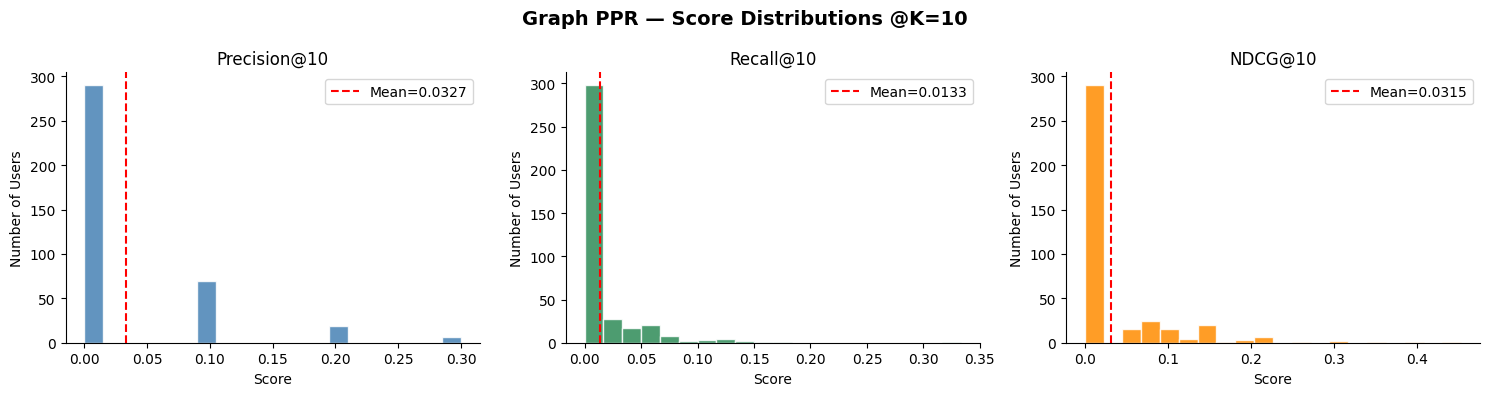

 Score distribution chart saved.


In [41]:
# Visualization: Per-User Score Distribution

# This visualization shows the distribution of evaluation scores
# (Precision, Recall, and NDCG) across all users.

# It helps analyze how the model performs at the individual level,
# rather than relying only on average metrics.


# Create subplots for three metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Set main title for the figure
fig.suptitle(f'Graph PPR — Score Distributions @K={K}',
             fontsize=14, fontweight='bold')

# Define metrics, labels, and colors for plotting
metrics = [
    (precision_scores, f'Precision@{K}', 'steelblue'),
    (recall_scores,    f'Recall@{K}',    'seagreen'),
    (ndcg_scores,      f'NDCG@{K}',      'darkorange')
]

# Plot histogram for each metric
for ax, (scores, label, color) in zip(axes, metrics):
    ax.hist(scores, bins=20, color=color, edgecolor='white', alpha=0.85) # Plot distribution of scores across users
    ax.axvline(np.mean(scores), color='red', linestyle='--', # Add vertical line to indicate average score
               linewidth=1.5, label=f'Mean={np.mean(scores):.4f}')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Users')
    ax.legend()
    sns.despine(ax=ax) # Remove top/right borders for cleaner visualization

plt.tight_layout()
plt.savefig('ppr_score_distributions.png', dpi=150, bbox_inches='tight') # Save figure for reporting
plt.show()
print(" Score distribution chart saved.")

In [42]:
# Evaluation at Different K Values

# In this step, we evaluate the recommendation model at multiple
# values of K to analyze how performance changes as the number
# of recommended items increases.

# This helps understand the trade-off between Precision, Recall,
# and ranking quality (NDCG).


# Different cutoff values for evaluation
k_values  = [1, 3, 5, 10, 15, 20]
k_results = []

for k in k_values:
    p_scores = []
    r_scores = []
    n_scores = []

    for uid in test_users_in_graph:
        recommended = all_recommendations.get(uid, [])
        actual      = ground_truth.get(uid, [])
        if not actual:
            continue
        p_scores.append(precision_at_k(recommended, actual, k))
        r_scores.append(recall_at_k(recommended, actual, k))
        n_scores.append(ndcg_at_k(recommended, actual, k))

    # Store average metrics for current K
    k_results.append({
        'K'         : k,
        'Precision' : np.mean(p_scores),
        'Recall'    : np.mean(r_scores),
        'NDCG'      : np.mean(n_scores)
    })

# Convert results to DataFrame for analysis
k_results_df = pd.DataFrame(k_results)

print("Metrics at different K values:")
print(k_results_df.to_string(index=False))

Metrics at different K values:
 K  Precision   Recall     NDCG
 1   0.015584 0.000664 0.015584
 3   0.029437 0.003140 0.027091
 5   0.035844 0.007814 0.032256
10   0.032727 0.013272 0.031486
15   0.021818 0.013272 0.025237
20   0.016364 0.013272 0.022070


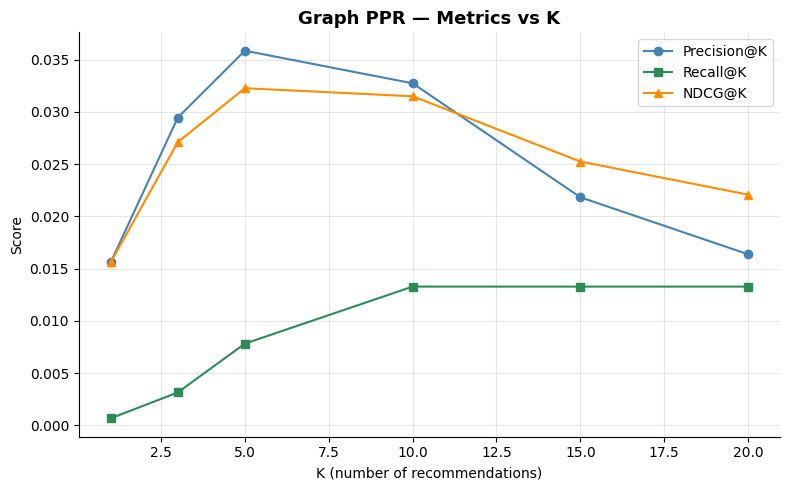

 Metrics vs K chart saved.


In [43]:
# Plot how evaluation metrics change as K increases

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_results_df['K'], k_results_df['Precision'],
        marker='o', label='Precision@K', color='steelblue')
ax.plot(k_results_df['K'], k_results_df['Recall'],
        marker='s', label='Recall@K',    color='seagreen')
ax.plot(k_results_df['K'], k_results_df['NDCG'],
        marker='^', label='NDCG@K',      color='darkorange')

ax.set_title('Graph PPR — Metrics vs K', fontsize=13, fontweight='bold')
ax.set_xlabel('K (number of recommendations)')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('ppr_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Metrics vs K chart saved.")

In [44]:
# STEP 6 — Visualization

# In this step, we create multiple visualizations to better
# understand the structure of the graph and the behavior
# of the recommendation model.

# The following visualizations are included:

# 6.1 Subgraph Visualization:
#     Displays a small portion of the bipartite graph,
#     illustrating the relationships between users and movies.

# 6.2 Recommendation Visualization:
#     For a selected user, shows:
#     - Movies liked in the training data
#     - Movies recommended by the model
#     - Movies actually liked in the test set
#     This helps visually assess recommendation quality.

# 6.3 Graph Statistics:
#     Shows degree distributions to analyze the overall
#     structure and connectivity of the graph.

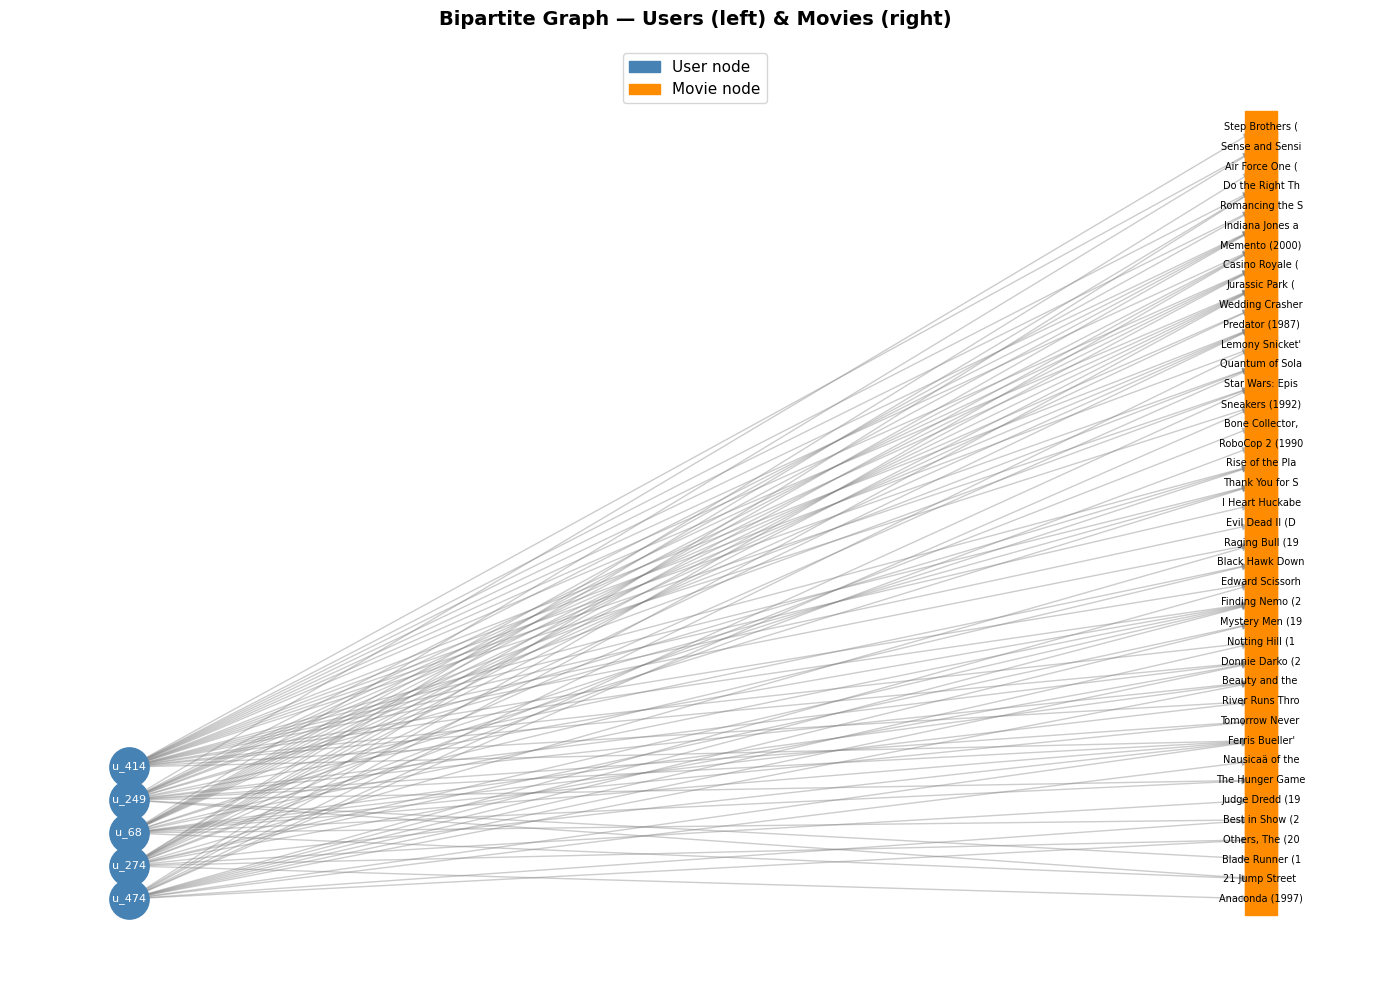

 Graph structure visualization saved.


In [45]:
# 6.1 — Subgraph Visualization

# Visualizing the entire graph with thousands of nodes would be
# cluttered and difficult to interpret. Therefore, we extract a
# smaller subgraph consisting of:
#   - A subset of highly active users
#   - A limited number of movies they interacted with

# This provides a clear and interpretable view of the bipartite
# structure between users and movies.

# COLOR CODE:
#   Blue circles   → User nodes
#   Orange squares → Movie nodes
#   Edges          → User–movie interactions

import matplotlib.patches as mpatches

# Select top 5 most active users (rich interaction patterns)
top_users = train_data['userId'].value_counts().head(5).index.tolist()

# Collect nodes: selected users and a subset of their connected movies
sub_nodes = [f"u_{uid}" for uid in top_users]

# Add up to 8 movie neighbors per user to keep the graph readable
for u_node in sub_nodes.copy():
    movie_neighbors = list(G.neighbors(u_node))
    sub_nodes.extend(movie_neighbors[:8])

# Build the subgraph
sub_nodes  = list(set(sub_nodes))
subgraph   = G.subgraph(sub_nodes)

# Separate nodes by type (user vs movie)
user_nodes_sub  = [n for n in subgraph.nodes()
                   if subgraph.nodes[n].get('type') == 'user']
movie_nodes_sub = [n for n in subgraph.nodes()
                   if subgraph.nodes[n].get('type') == 'movie']

# Manually assign positions to create a bipartite layout:
# users on the left, movies on the right
pos = {}
for i, node in enumerate(user_nodes_sub):
    pos[node] = (0, i * 2)
for i, node in enumerate(movie_nodes_sub):
    pos[node] = (3, i * 1.2)

# Draw
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_title('Bipartite Graph — Users (left) & Movies (right)',
             fontsize=14, fontweight='bold', pad=15)

# Draw user nodes
nx.draw_networkx_nodes(subgraph, pos,
                       nodelist=user_nodes_sub,
                       node_color='steelblue',
                       node_size=800,
                       node_shape='o',
                       ax=ax)

# Draw movie nodes
nx.draw_networkx_nodes(subgraph, pos,
                       nodelist=movie_nodes_sub,
                       node_color='darkorange',
                       node_size=500,
                       node_shape='s',
                       ax=ax)

# Draw edges
nx.draw_networkx_edges(subgraph, pos,
                       edge_color='gray',
                       alpha=0.4,
                       arrows=True,
                       arrowsize=10,
                       ax=ax)

# Draw user labels (just the ID)
user_labels = {n: n for n in user_nodes_sub}
nx.draw_networkx_labels(subgraph, pos,
                        labels=user_labels,
                        font_size=8,
                        font_color='white',
                        ax=ax)

# Display user IDs and shortened movie titles
movie_labels = {
    n: subgraph.nodes[n].get('title', n)[:15]
    for n in movie_nodes_sub
}
nx.draw_networkx_labels(subgraph, pos,
                        labels=movie_labels,
                        font_size=7,
                        font_color='black',
                        ax=ax)

# Add legend to explain node types
legend_elements = [
    mpatches.Patch(color='steelblue',   label='User node'),
    mpatches.Patch(color='darkorange',  label='Movie node')
]
ax.legend(handles=legend_elements, loc='upper center', fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.savefig('graph_structure.png', dpi=150, bbox_inches='tight') # Save visualization for reporting
plt.show()
print(" Graph structure visualization saved.")

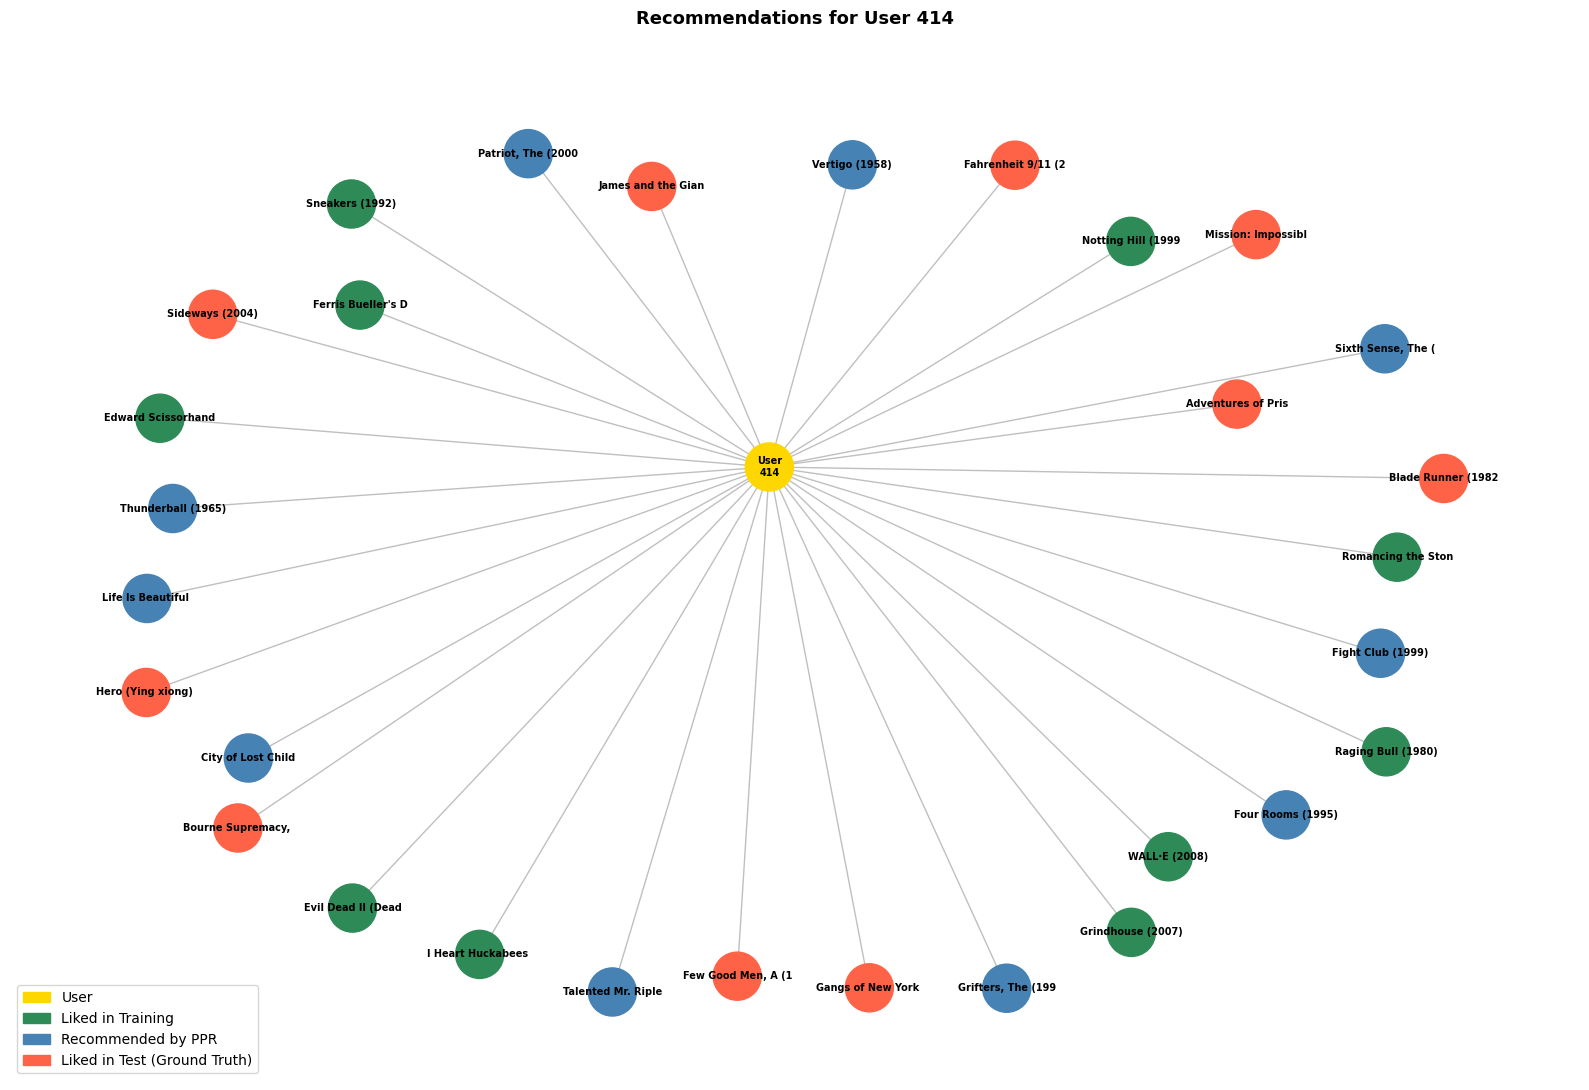

  Visualization saved.
   Recommended : 10 movies
   Test liked  : 10 movies
   Hits     : 0 correct recommendations


In [46]:
# 6.2 — Recommendation Visualization (Sample User)

# This visualization presents the recommendation results for a single user
# using a star-shaped graph layout.

# Three categories of movies are displayed:
#   - Training (green): Movies the user has already liked
#   - Recommended (blue): Movies suggested by the PPR model
#   - Ground Truth (red): Movies the user actually liked in the test set

# The overlap between recommended and ground truth items
# represents correct recommendations, providing an intuitive
# visual interpretation of model performance.


# Select a highly active user for meaningful visualization
viz_uid   = train_data['userId'].value_counts().index[0]
viz_unode = f"u_{viz_uid}"


# Collect the three sets of movies

# Movies liked in training (already seen by the user)
train_movies = train_data[
    train_data['userId'] == viz_uid
]['movieId'].tolist()[:10]

# Movies recommended by the PPR model
rec_movies = all_recommendations.get(viz_uid, [])[:10]

# Ground truth: movies liked in the test set
test_movies = test_data[
    test_data['userId'] == viz_uid
]['movieId'].tolist()[:10]

# Create a small graph centered on the selected user
viz_G   = nx.DiGraph()
viz_G.add_node(viz_unode, type='user')

# Helper function to shorten movie titles for readability
def short_title(movie_id, max_len=18):
    row = movies[movies['movieId'] == movie_id]
    if row.empty:
        return f"m_{movie_id}"
    return row['title'].values[0][:max_len]

# Add nodes and edges for each category (train, recommended, test)
for mid in train_movies:
    label = short_title(mid)
    viz_G.add_node(f"m_{mid}", type='train', label=label)
    viz_G.add_edge(viz_unode, f"m_{mid}")

for mid in rec_movies:
    label = short_title(mid)
    viz_G.add_node(f"m_{mid}", type='rec', label=label)
    viz_G.add_edge(viz_unode, f"m_{mid}")

for mid in test_movies:
    label = short_title(mid)
    if f"m_{mid}" not in viz_G.nodes():
        viz_G.add_node(f"m_{mid}", type='test', label=label)
    viz_G.add_edge(viz_unode, f"m_{mid}")

# Use spring layout to position nodes around the central user
pos_viz = nx.spring_layout(viz_G, seed=42, k=2.5)

# Assign colors based on node type for visual distinction
color_map = []
for node in viz_G.nodes():
    ntype = viz_G.nodes[node].get('type', '')
    if ntype == 'user':
        color_map.append('gold')
    elif ntype == 'train':
        color_map.append('seagreen')
    elif ntype == 'rec':
        color_map.append('steelblue')
    elif ntype == 'test':
        color_map.append('tomato')
    else:
        color_map.append('lightgray')

# Create labels for nodes (user + movie titles)
node_labels = {}
for node in viz_G.nodes():
    if viz_G.nodes[node].get('type') == 'user':
        node_labels[node] = f"User\n{viz_uid}"
    else:
        node_labels[node] = viz_G.nodes[node].get('label', node)

# Draw nodes, edges, and labels
fig, ax = plt.subplots(figsize=(16, 11))
ax.set_title(
    f'Recommendations for User {viz_uid}\n',
    fontsize=13, fontweight='bold', pad=15
)

nx.draw_networkx_nodes(viz_G, pos_viz,
                       node_color=color_map,
                       node_size=1200,
                       ax=ax)
nx.draw_networkx_edges(viz_G, pos_viz,
                       edge_color='gray',
                       alpha=0.5,
                       arrows=True,
                       arrowsize=12,
                       ax=ax)
nx.draw_networkx_labels(viz_G, pos_viz,
                        labels=node_labels,
                        font_size=7,
                        font_weight='bold',
                        ax=ax)

# Add legend to explain color categories
legend_elements = [
    mpatches.Patch(color='gold',      label='User'),
    mpatches.Patch(color='seagreen',  label='Liked in Training'),
    mpatches.Patch(color='steelblue', label='Recommended by PPR'),
    mpatches.Patch(color='tomato',    label='Liked in Test (Ground Truth)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.savefig('user_recommendations_viz.png', dpi=150, bbox_inches='tight') # Save visualization for reporting
plt.show()

# Print overlap (hits)
hits = set(rec_movies) & set(test_movies) # Compute overlap between recommended and ground truth movies
print(f"  Visualization saved.")
print(f"   Recommended : {len(rec_movies)} movies")
print(f"   Test liked  : {len(test_movies)} movies")
print(f"   Hits     : {len(hits)} correct recommendations")


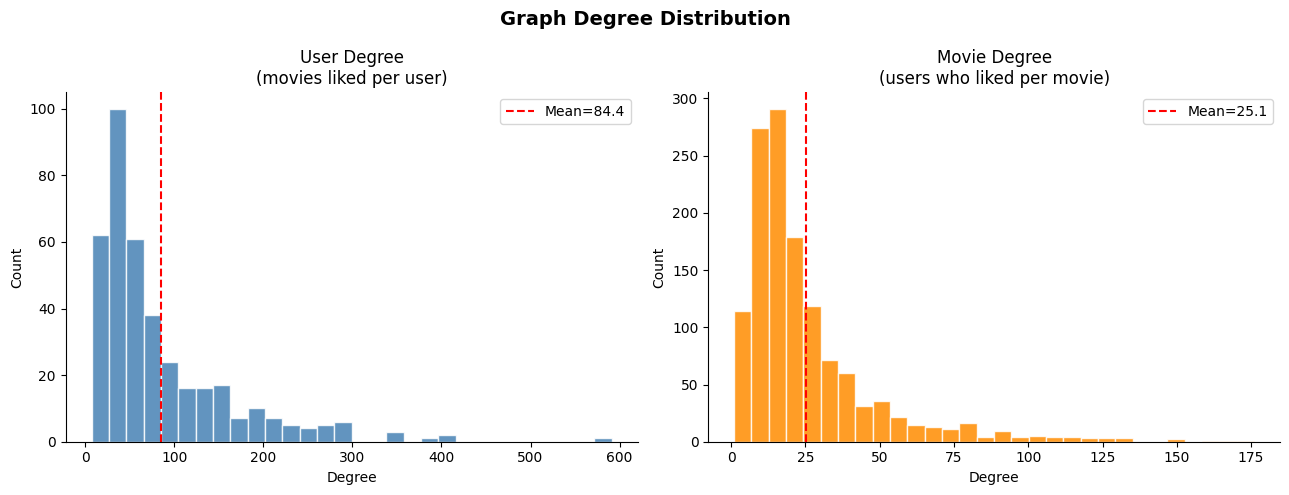

 Degree distribution chart saved.


In [47]:
#6.3 — Graph Degree Distribution

# In this step, we analyze the connectivity of the graph by
# examining the degree distribution of users and movies.

# Degree represents the number of connections (edges):
#   - User degree  = number of movies the user interacted with
#   - Movie degree = number of users who interacted with the movie

# This helps us understand:
#   - User activity levels
#   - Movie popularity patterns
#   - Overall graph structure


# Compute degree for each user (number of liked movies)
user_degrees  = [G.out_degree(f"u_{uid}")
                 for uid in train_data['userId'].unique()
                 if f"u_{uid}" in G]

# Compute degree for each movie (number of users who liked it)
movie_degrees = [G.in_degree(f"m_{mid}")
                 for mid in train_data['movieId'].unique()
                 if f"m_{mid}" in G]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Graph Degree Distribution', fontsize=14, fontweight='bold')

ax1.hist(user_degrees,  bins=30, color='steelblue',
         edgecolor='white', alpha=0.85)
ax1.set_title('User Degree\n(movies liked per user)')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Count')
ax1.axvline(np.mean(user_degrees), color='red', linestyle='--', # Add vertical line to show average degree
            label=f'Mean={np.mean(user_degrees):.1f}')
ax1.legend()
sns.despine(ax=ax1)

ax2.hist(movie_degrees, bins=30, color='darkorange',
         edgecolor='white', alpha=0.85)
ax2.set_title('Movie Degree\n(users who liked per movie)')
ax2.set_xlabel('Degree')
ax2.set_ylabel('Count')
ax2.axvline(np.mean(movie_degrees), color='red', linestyle='--',
            label=f'Mean={np.mean(movie_degrees):.1f}')
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Degree distribution chart saved.")

In [48]:
# EXTENSION 1 — Graph Neural Networks (GNN)

# Objective:
# Enhance recommendation quality by learning node embeddings
# using a Graph Neural Network instead of relying on
# hand-crafted algorithms like Personalized PageRank (PPR).

# Why GNN instead of PPR?
# - PPR is a fixed, heuristic-based algorithm that ranks nodes
#   using random walk probabilities.
# - It does not learn patterns from data.
# - GNNs, on the other hand, learn representations directly
#   from the graph structure through training.

# Key Idea:
# A GNN learns low-dimensional embeddings for users and movies
# by aggregating information from their neighbors in the graph.

# These embeddings capture:
#   - User preferences (based on connected items)
#   - Item similarity (based on shared users)
#   - Higher-order relationships (multi-hop connections)

# Model Used — LightGCN:
# LightGCN is a simplified and highly effective GNN model
# designed specifically for recommendation systems.

# Key characteristics:
# - Removes feature transformation layers
# - Removes non-linear activation functions
# - Focuses only on neighborhood aggregation

# Architecture:
#   Input: Randomly initialized embeddings for users and movies
#   Layer 1: Aggregate embeddings from 1-hop neighbors
#   Layer 2: Aggregate embeddings from 2-hop neighbors
#   Layer 3: Aggregate embeddings from 3-hop neighbors
#   Output: Final embedding = average of all layer embeddings
#   Scoring: Recommendation score = dot product(user_embedding, movie_embedding)

In [49]:
# STEP 7 — Setup for Graph Neural Networks (GNN)

# In this step, we install and import PyTorch Geometric (PyG),
# a specialized library for building Graph Neural Networks.

# PyG provides efficient implementations of graph operations,
# including message passing and graph convolution layers.

# Install PyTorch Geometric
!pip install torch-geometric --quiet

# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim

from torch_geometric.data import Data
from torch_geometric.nn import LGConv   # LightGCN layer

print("PyTorch Geometric installed successfully.")
print(f"PyTorch version: {torch.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.2 MB/s eta 0:00:00
PyTorch Geometric installed successfully.
PyTorch version: 2.11.0+cpu


In [50]:
# Encode User and Movie IDs

# Neural networks cannot work directly with raw IDs (e.g., userId, movieId).
# Instead, we map each user and movie to a continuous integer index:
#   userId  → user_idx  (0 ... N-1)
#   movieId → movie_idx (0 ... M-1)
# These indices are used to access embedding vectors in the model.


# Initialize encoders for users and movies
user_encoder  = LabelEncoder()
movie_encoder = LabelEncoder()

# Fit encoders on training data and generate indices
train_data['user_idx']  = user_encoder.fit_transform(train_data['userId'])
train_data['movie_idx'] = movie_encoder.fit_transform(train_data['movieId'])

# Apply the same encoding to test data without refitting
# to avoid data leakage
test_data['user_idx'] = test_data['userId'].apply(
    lambda x: user_encoder.transform([x])[0]
    if x in user_encoder.classes_ else -1   # Assign -1 to unseen users
)
test_data['movie_idx'] = test_data['movieId'].apply(
    lambda x: movie_encoder.transform([x])[0]
    if x in movie_encoder.classes_ else -1   # Assign -1 to unseen movies
)

# Remove interactions with unseen users or movies
test_data_gnn = test_data[
    (test_data['user_idx'] != -1) &
    (test_data['movie_idx'] != -1)
].copy()

# Total number of unique users and movies
NUM_USERS  = train_data['user_idx'].nunique()
NUM_MOVIES = train_data['movie_idx'].nunique()

print(f" Encodings created.")
print(f"   Number of users  : {NUM_USERS}")
print(f"   Number of movies : {NUM_MOVIES}")
print(f"   Total nodes      : {NUM_USERS + NUM_MOVIES}")


 Encodings created.
   Number of users  : 385
   Number of movies : 1296
   Total nodes      : 1681


In [51]:
# Build the Edge Index for PyTorch Geometric (PyG)

# PyG represents a graph using an "edge_index" tensor:
#   Shape: [2, num_edges]
#   Row 0 → source nodes
#   Row 1 → destination nodes

# To combine users and movies in a single graph, we assign:
#   Users  → indices from 0 to NUM_USERS-1
#   Movies → indices from NUM_USERS to NUM_USERS+NUM_MOVIES-1
# This avoids index overlap between users and movies.

# We shift (offset) movie indices by NUM_USERS to ensure
# all nodes exist in a single unified index space.

# We create edges in BOTH directions:
#   user → movie
#   movie → user
# This is required for GNN message passing, so that:
#   - Users receive information from movies
#   - Movies receive information from users


user_indices  = torch.tensor(train_data['user_idx'].values,  dtype=torch.long)
movie_indices = torch.tensor(train_data['movie_idx'].values, dtype=torch.long) + NUM_USERS

# Create bidirectional edges:
# - user → movie (interaction)
# - movie → user (reverse edge for message passing)
edge_index = torch.stack([
    torch.cat([user_indices,  movie_indices]),   # sources
    torch.cat([movie_indices, user_indices])     # destinations
], dim=0)

print(f" Edge index built.")
print(f"   Shape      : {edge_index.shape}")
print(f"   Total edges: {edge_index.shape[1]} "
      f"({edge_index.shape[1]//2} interactions × 2 directions)")

 Edge index built.
   Shape      : torch.Size([2, 65000])
   Total edges: 65000 (32500 interactions × 2 directions)


In [52]:
# Define the LightGCN Model

class LightGCN(nn.Module):
    """
LightGCN model for recommendation.

Each user and movie is represented by a learnable embedding vector.
The model propagates embeddings through multiple graph convolution
layers, where each node aggregates information from its neighbors.

Final embeddings are computed by averaging representations from
all layers. Recommendation scores are computed using the dot
product between user and movie embeddings.
    """

    def __init__(self, num_users, num_movies,
                 embedding_dim=64, num_layers=3):
        super(LightGCN, self).__init__()

        self.num_users     = num_users
        self.num_movies    = num_movies
        self.embedding_dim = embedding_dim
        self.num_layers    = num_layers

        # Learnable embeddings:
        # Each user and movie is assigned a vector representation
        # that is optimized during training.
        self.user_embedding  = nn.Embedding(num_users,  embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)

        # LightGCN layers:
        # Each layer aggregates (averages) embeddings from neighboring nodes
        # without applying transformations or activation functions.
        self.convs = nn.ModuleList([
            LGConv() for _ in range(num_layers)
        ])

        # Initialize embeddings using Xavier initialization
        # to ensure stable gradients during early training
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.movie_embedding.weight)

    def forward(self, edge_index):
        """
        Forward pass: propagate embeddings through graph layers.
        Returns final user and movie embeddings.
        """

        # Combine user and movie embeddings into a single matrix
        # Shape: [num_users + num_movies, embedding_dim]
        x = torch.cat([
            self.user_embedding.weight,
            self.movie_embedding.weight
        ], dim=0)

        # Store embeddings from each layer
        all_embeddings = [x]

        # Propagate embeddings through the graph:
        # Each node updates its representation by aggregating
        # embeddings from its neighbors (message passing)
        for conv in self.convs:
            x = conv(x, edge_index)
            all_embeddings.append(x)

        # Final embedding = average across all layers
        # Average embeddings from all layers to capture
        # both local (1-hop) and higher-order (multi-hop) relationships
        final_emb = torch.stack(all_embeddings, dim=0).mean(dim=0)

        # Split back into user and movie embeddings
        user_emb  = final_emb[:self.num_users]
        movie_emb = final_emb[self.num_users:]

        return user_emb, movie_emb

    def predict(self, user_indices, movie_indices, edge_index):
        """
        Predict scores for (user, movie) pairs.
        Score = dot product of their final embeddings.
        Higher score = stronger recommendation.
        """
        user_emb, movie_emb = self.forward(edge_index)
        u = user_emb[user_indices]
        m = movie_emb[movie_indices]
        return (u * m).sum(dim=1)   # Compute dot product between user and movie embeddings


# Instantiate the model
EMBEDDING_DIM = 64
NUM_LAYERS    = 3

gnn_model = LightGCN(
    num_users   = NUM_USERS,
    num_movies  = NUM_MOVIES,
    embedding_dim = EMBEDDING_DIM,
    num_layers  = NUM_LAYERS
)

print(gnn_model)
total_params = sum(p.numel() for p in gnn_model.parameters())
print(f"\n Model created.")
print(f"   Embedding dim  : {EMBEDDING_DIM}")
print(f"   GCN layers     : {NUM_LAYERS}")
print(f"   Total params   : {total_params:,}")

LightGCN(
  (user_embedding): Embedding(385, 64)
  (movie_embedding): Embedding(1296, 64)
  (convs): ModuleList(
    (0-2): 3 x LGConv()
  )
)

 Model created.
   Embedding dim  : 64
   GCN layers     : 3
   Total params   : 107,584


Training LightGCN for 20 epochs...
────────────────────────────────────────
  Epoch   1/20  |  Loss: 0.6925
  Epoch   5/20  |  Loss: 0.5926
  Epoch  10/20  |  Loss: 0.5484
  Epoch  15/20  |  Loss: 0.5226
  Epoch  20/20  |  Loss: 0.4950

 Training complete.


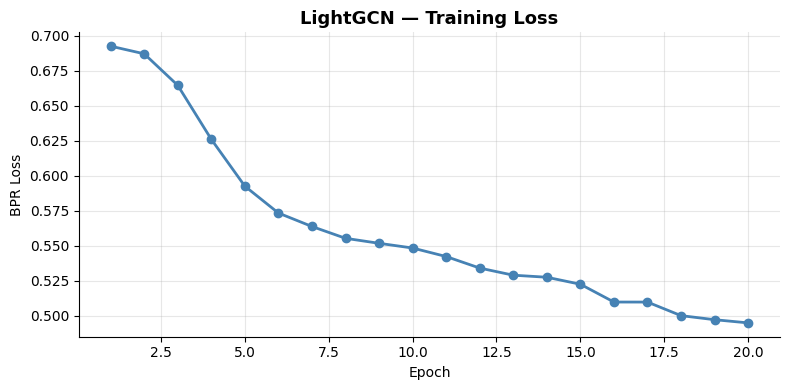

In [53]:
# Train LightGCN using BPR Loss

# We train the model using Bayesian Personalized Ranking (BPR),
# which is designed for implicit feedback (e.g., user interactions).

# Instead of predicting ratings, BPR learns to rank items:
#   positive items (liked) > negative items (not interacted)

# For each (user, positive movie), we sample a negative movie
# and train the model to assign a higher score to the positive one.

# Loss function:
#   BPR Loss = -log(sigmoid(score_pos - score_neg))

EPOCHS    = 20
LR        = 0.001
BATCH     = 1024

optimizer = optim.Adam(gnn_model.parameters(), lr=LR)

# Prepare positive pairs as tensors
pos_users  = torch.tensor(train_data['user_idx'].values,  dtype=torch.long)
pos_movies = torch.tensor(train_data['movie_idx'].values, dtype=torch.long)

train_losses = []

print(f"Training LightGCN for {EPOCHS} epochs...")
print("─" * 40)

gnn_model.train()

for epoch in range(EPOCHS):

    total_loss  = 0
    num_batches = 0

    # Mini-batch training
    for start in range(0, len(pos_users), BATCH):

        end = start + BATCH
        batch_users  = pos_users[start:end]
        batch_pos    = pos_movies[start:end]

        # Sample negative movies:
        # For each (user, positive movie), we randomly sample a movie
        # assumed to be not interacted with by the user.
        # This provides a contrast for learning preference ranking.
        batch_neg = torch.randint(0, NUM_MOVIES, (len(batch_users),))

        # Compute predicted scores for positive and negative pairs
        score_pos = gnn_model.predict(batch_users, batch_pos, edge_index)
        score_neg = gnn_model.predict(batch_users, batch_neg, edge_index)

        # Compute BPR loss:
        # Encourages score_pos > score_neg
        loss = -torch.log(torch.sigmoid(score_pos - score_neg)).mean()

        # Backpropagation: update model parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss  += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS}  |  Loss: {avg_loss:.4f}")

print("\n Training complete.")

# Plot training loss over epochs to monitor learning progress
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses,
         marker='o', color='steelblue', linewidth=2)
plt.title('LightGCN — Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('gnn_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:
# Generate Recommendations using LightGCN

# After training, we obtain the final user and movie embeddings
# from the model.

# Recommendation scores are computed using the dot product
# between user and movie embeddings:
#   score(u, m) = user_embedding ⋅ movie_embedding

# We compute a full score matrix:
#   Rows    → users
#   Columns → movies
# Each entry represents the predicted preference score.


# Set model to evaluation mode and disable gradient computation
gnn_model.eval()
with torch.no_grad():
    user_emb, movie_emb = gnn_model.forward(edge_index)

# user_emb  shape: [NUM_USERS,  EMBEDDING_DIM]
# movie_emb shape: [NUM_MOVIES, EMBEDDING_DIM]

# Compute full user–item score matrix using matrix multiplication
# Shape: [NUM_USERS, NUM_MOVIES]
score_matrix = torch.matmul(user_emb, movie_emb.T).numpy()

print(f" Score matrix computed: {score_matrix.shape}")
print(f"   Rows = users ({NUM_USERS}), Cols = movies ({NUM_MOVIES})")

 Score matrix computed: (385, 1296)
   Rows = users (385), Cols = movies (1296)


In [55]:
# Evaluate GNN Model (LightGCN)

# We evaluate the GNN model using the same metrics as before:
# Precision@K, Recall@K, and NDCG@K.

# Using the same evaluation setup ensures a fair comparison
# between the GNN model and the PPR baseline.

K = 10

gnn_precision_scores = []
gnn_recall_scores    = []
gnn_ndcg_scores      = []

# Build lookup of movies already seen by each user (training data)
# Used to avoid recommending previously interacted items
seen_movies_per_user = train_data.groupby('user_idx')['movie_idx'].apply(set).to_dict()

gnn_all_recommendations = {}

for uid in test_users_in_graph:

    # Convert original userId to encoded index used by the model
    if uid not in user_encoder.classes_:
        continue
    u_idx = user_encoder.transform([uid])[0]

    # Retrieve predicted scores for all movies for this user
    user_scores = score_matrix[u_idx].copy()

    # Exclude movies already seen in training by assigning -inf
    # so they are never selected in top-K recommendations
    seen = seen_movies_per_user.get(u_idx, set())
    for m_idx in seen:
        user_scores[m_idx] = -np.inf

    # Select top-K movies with highest predicted scores
    top_k_idx = np.argsort(user_scores)[::-1][:K]

    # Convert encoded indices back to original movie IDs
    top_k_movie_ids = movie_encoder.inverse_transform(top_k_idx).tolist()
    gnn_all_recommendations[uid] = top_k_movie_ids

    # Retrieve ground truth movies (test set)
    actual = ground_truth.get(uid, [])
    if not actual:
        continue


    # Compute evaluation metrics for this user
    gnn_precision_scores.append(precision_at_k(top_k_movie_ids, actual, K))
    gnn_recall_scores.append(recall_at_k(top_k_movie_ids, actual, K))
    gnn_ndcg_scores.append(ndcg_at_k(top_k_movie_ids, actual, K))


# Compute average metrics across all users
avg_gnn_precision = np.mean(gnn_precision_scores)
avg_gnn_recall    = np.mean(gnn_recall_scores)
avg_gnn_ndcg      = np.mean(gnn_ndcg_scores)

print(f"  GNN (LightGCN) — Evaluation @K={K}")

print(f"  Precision@{K} : {avg_gnn_precision:.4f}")
print(f"  Recall@{K}    : {avg_gnn_recall:.4f}")
print(f"  NDCG@{K}      : {avg_gnn_ndcg:.4f}")

# Save for final comparison
gnn_results = {
    'model'     : 'GNN (LightGCN)',
    'precision' : avg_gnn_precision,
    'recall'    : avg_gnn_recall,
    'ndcg'      : avg_gnn_ndcg
}

  GNN (LightGCN) — Evaluation @K=10
  Precision@10 : 0.1953
  Recall@10    : 0.1148
  NDCG@10      : 0.2241


In [56]:
# EXTENSION 2 — Content-Based Features (Movie Genres)

# Objective:
# Enhance recommendation performance by incorporating
# content-based features (movie genres) alongside
# collaborative filtering signals.

# Current limitation:
# Previous models (PPR, GNN) rely only on collaborative signals:
#   "users who liked similar items also liked X"

# Content-based approach adds:
#   "items are similar because they share intrinsic properties
#    such as genre"

# Motivation:
# Two movies may have no shared users but still be similar
# (e.g., both are Sci-Fi thrillers). Content features help
# capture such relationships.

# This is particularly useful for:
#   - Cold-start items (new movies with few interactions)
#   - Improving diversity and coverage of recommendations

# Plan:
#   1. Extract genres from the dataset (pipe-separated strings)
#   2. Convert genres into one-hot encoded feature vectors
#   3. Add similarity edges between movies based on genre overlap
#   4. Use genre features as node attributes in the GNN
#   5. Implement a pure content-based recommender
#   6. Build a hybrid model combining collaborative + content

In [57]:
# Extract Movie Genres

# In this step, we load the movie metadata and extract
# genre information for each movie.

# The "genres" column contains pipe-separated values:
#   e.g. "Adventure|Animation|Comedy"

# These will later be split into individual genre tokens
# and transformed into feature vectors for content-based modeling.

# Load movie metadata (including genre information)
movies_genres = pd.read_csv('movies.csv')

print("Movies sample:")
print(movies_genres.head())
print("\nColumns:", movies_genres.columns.tolist())

Movies sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Columns: ['movieId', 'title', 'genres']


In [58]:
# Parse and One-Hot Encode Genres

# In this step, we convert raw genre strings into structured
# numerical features.

# Process:
#   1. Split pipe-separated genre strings into lists
#   2. Collect all unique genres in the dataset
#   3. Represent each movie as a binary (one-hot) vector

# Example:
#   "Action|Drama" → [Action=1, Drama=1, Comedy=0, ...]

# These feature vectors will later be used to measure
# content similarity between movies.

# Replace missing or empty genres with 'Unknown'
movies_genres['genres'] = movies_genres['genres'].fillna('Unknown')

# Convert genre string into list of individual genres
movies_genres['genre_list'] = movies_genres['genres'].apply(
    lambda x: x.split('|') if x != '(no genres listed)' else ['Unknown'] # Handle special case where no genres are listed
)

# Extract all unique genre labels from the dataset
all_genres = sorted(set(
    genre
    for genre_list in movies_genres['genre_list']
    for genre in genre_list
))

print(f"Total unique genres found: {len(all_genres)}")
print(f"Genres: {all_genres}")

Total unique genres found: 20
Genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'Unknown', 'War', 'Western']


In [59]:
# Build Genre Feature Matrix

# In this step, we convert genre lists into one-hot encoded
# feature vectors for each movie.

# Each movie is represented by a binary vector of length equal
# to the number of unique genres:
#   1 → movie belongs to the genre
#   0 → movie does not belong to the genre

# The result is a feature matrix:
#   Shape: [num_movies, num_genres]

# This matrix will be used for:
#   - Measuring similarity between movies
#   - Incorporating content features into the GNN

# Create one-hot encoded features for each genre
for genre in all_genres:
    movies_genres[genre] = movies_genres['genre_list'].apply(
        lambda g_list: 1 if genre in g_list else 0   # Assign 1 if the movie contains the genre, else 0
    )

# List of feature column names (one per genre)
genre_feature_cols = all_genres
genre_matrix = movies_genres[genre_feature_cols].values  # Convert genre features into a NumPy matrix for modeling

print(f" Genre feature matrix shape: {genre_matrix.shape}")
print(f"   Rows = movies ({genre_matrix.shape[0]})")
print(f"   Cols = genres ({genre_matrix.shape[1]})")
print("\nSample movie genre vector:")
sample_movie = movies_genres.iloc[0]
print(f"  Movie : {sample_movie['title']}")
print(f"  Genres: {sample_movie['genre_list']}")
print(f"  Vector: {genre_matrix[0]}")

 Genre feature matrix shape: (9742, 20)
   Rows = movies (9742)
   Cols = genres (20)

Sample movie genre vector:
  Movie : Toy Story (1995)
  Genres: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']
  Vector: [0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [60]:
# Add Genre Similarity Edges to the Graph

# Objective:
# Enhance the graph by adding edges between movies that are
# similar based on their genre features.

# Motivation:
# Two movies may not share users but can still be similar
# in content (e.g., both are Action + Sci-Fi).
# Adding these edges allows the model to capture content-based
# relationships in addition to collaborative signals.

# Similarity Metric — Cosine Similarity:
# Measures similarity between genre vectors.
# Ranges from 0 (no similarity) to 1 (identical vectors).

# We only add edges when similarity ≥ threshold
# to avoid creating a fully connected graph.

# These edges act as shortcuts, enabling information flow
# between similar movies in both PPR and GNN models.

from sklearn.metrics.pairwise import cosine_similarity

SIMILARITY_THRESHOLD = 0.5

# Select movies that appear in the training data
train_movie_ids = train_data['movieId'].unique()
movies_in_train = movies_genres[
    movies_genres['movieId'].isin(train_movie_ids)
].reset_index(drop=True)

# Extract genre feature vectors for selected movies
train_genre_matrix = movies_in_train[genre_feature_cols].values

# Compute pairwise cosine similarity between movie feature vectors
# Shape: [num_train_movies, num_train_movies]
genre_sim_matrix = cosine_similarity(train_genre_matrix)

print(f"Genre similarity matrix shape: {genre_sim_matrix.shape}")

# Add movie-movie edges to the graph
genre_edges_added = 0
movie_id_list     = movies_in_train['movieId'].tolist()

for i in range(len(movie_id_list)):
    for j in range(i + 1, len(movie_id_list)):
        sim = genre_sim_matrix[i][j]
        if sim >= SIMILARITY_THRESHOLD:
            m_i = f"m_{movie_id_list[i]}"
            m_j = f"m_{movie_id_list[j]}"
            # Add bidirectional edges weighted by similarity score
            # Add edges in both directions to enable bidirectional
            # message passing and graph traversal
            if m_i in G and m_j in G:
                G.add_edge(m_i, m_j, weight=sim)
                G.add_edge(m_j, m_i, weight=sim)
                genre_edges_added += 2

print(f"\n Added {genre_edges_added} genre similarity edges to graph.")
print(f"   Total graph edges now: {G.number_of_edges()}")

Genre similarity matrix shape: (1296, 1296)

 Added 372948 genre similarity edges to graph.
   Total graph edges now: 405448


In [61]:
# Pure Content-Based Recommender

# Objective:
# Build a recommendation model based solely on content features
# (movie genres), without using any collaborative information.

# Approach:
#   1. Identify movies the user liked in the training data
#   2. Compute the user's profile as the average of their
#      liked movie genre vectors
#   3. Measure similarity between the user profile and all
#      unseen movies using cosine similarity
#   4. Recommend the top-N most similar movies

# This model answers:
#   "Which movies match the user's preferred genres?"

# This serves as a baseline to compare against:
#   - Collaborative methods (PPR)
#   - GNN-based models
#   - Hybrid approaches

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Create a mapping from movieId to its genre feature vector
movie_genre_lookup = {}
for _, row in movies_in_train.iterrows():
    movie_genre_lookup[row['movieId']] = row[genre_feature_cols].values.astype(float)

def content_based_recommend(user_id, train_df, movie_genre_lookup,
                             all_movie_ids, top_n=10):
    """
    Pure content-based recommendations using genre similarity.

    1. Build user profile = average genre vector of liked movies
    2. Score all unseen movies by cosine similarity to profile
    3. Return top-N most similar unseen movies
    """

    # Retrieve movies the user interacted with in training
    user_liked = train_df[train_df['userId'] == user_id]['movieId'].tolist()

    if not user_liked:
        return []

    # Build user profile by averaging genre vectors of liked movies
    liked_vectors = [
        movie_genre_lookup[mid]
        for mid in user_liked
        if mid in movie_genre_lookup
    ]

    if not liked_vectors:
        return []

    # Compute user preference vector (average of liked movie features)
    user_profile = np.mean(liked_vectors, axis=0).reshape(1, -1)

    # Compute similarity scores for unseen movies only
    scores = []
    seen   = set(user_liked)

    for mid, vec in movie_genre_lookup.items():
        if mid not in seen:
            similarity = cos_sim(user_profile, vec.reshape(1, -1))[0][0]
            scores.append((mid, similarity))

    # Rank movies by similarity (highest first)
    scores.sort(key=lambda x: x[1], reverse=True)
    return [mid for mid, _ in scores[:top_n]]


print(" Content-based recommender defined.")

 Content-based recommender defined.


In [62]:
# Evaluate Content-Based Model

# We evaluate the content-based recommender using the same
# metrics as previous models:
#   - Precision@K
#   - Recall@K
#   - NDCG@K

# Using the same evaluation protocol ensures a fair comparison
# with collaborative (PPR) and GNN-based models.


# Number of recommendations per user
K = 10

# Store evaluation scores across users
cb_precision_scores = []
cb_recall_scores    = []
cb_ndcg_scores      = []
cb_all_recs         = {}

# List of candidate movies for recommendation
all_movie_ids_in_train = list(movie_genre_lookup.keys())

# Generate top-K recommendations using content-based model
for uid in test_users_in_graph:
    recs   = content_based_recommend(
        uid, train_data,
        movie_genre_lookup,
        all_movie_ids_in_train,
        top_n=K
    )
    actual = ground_truth.get(uid, []) # Retrieve ground truth interactions (test set)
    cb_all_recs[uid] = recs

    # Skip users with no ground truth data
    if not actual:
        continue

    # Compute evaluation metrics for this user
    cb_precision_scores.append(precision_at_k(recs, actual, K))
    cb_recall_scores.append(recall_at_k(recs, actual, K))
    cb_ndcg_scores.append(ndcg_at_k(recs, actual, K))

# Compute average performance across users
avg_cb_precision = np.mean(cb_precision_scores)
avg_cb_recall    = np.mean(cb_recall_scores)
avg_cb_ndcg      = np.mean(cb_ndcg_scores)

print("=" * 45)
print(f"  Content-Based — Evaluation @K={K}")
print("=" * 45)
print(f"  Precision@{K} : {avg_cb_precision:.4f}")
print(f"  Recall@{K}    : {avg_cb_recall:.4f}")
print(f"  NDCG@{K}      : {avg_cb_ndcg:.4f}")
print("=" * 45)

cb_results = {
    'model'     : 'Content-Based',
    'precision' : avg_cb_precision,
    'recall'    : avg_cb_recall,
    'ndcg'      : avg_cb_ndcg
}

  Content-Based — Evaluation @K=10
  Precision@10 : 0.0408
  Recall@10    : 0.0247
  NDCG@10      : 0.0426


In [63]:
# Hybrid Recommender (PPR + Content-Based)

# Objective:
# Combine collaborative filtering (PPR) and content-based
# similarity into a unified recommendation model.

# Motivation:
# - PPR captures user behavior patterns (who liked what)
# - Content-based captures item similarity (what is similar)

# Hybrid approach leverages both:
#   - Improves recommendation accuracy
#   - Handles cold-start items
#   - Increases robustness

# Scoring:
#   hybrid_score = alpha * PPR_score + (1 - alpha) * content_score

# alpha controls the balance:
#   alpha → 1   → mostly collaborative
#   alpha → 0   → mostly content-based


ALPHA = 0.6   # weight for PPR scores

def hybrid_recommend(user_id, graph, user_node, train_df,
                     movie_genre_lookup, all_movie_ids,
                     alpha=0.6, top_n=10):
    """
    Hybrid recommendation combining PPR + content similarity.
    alpha controls PPR weight (1-alpha = content weight).
    """

    # Compute PPR-based scores
    ppr_raw = personalized_pagerank(
        graph, user_node,
        alpha=0.85,
        top_n=len(graph.nodes())
    )

    # Build dict: movieId → ppr_score
    ppr_dict = {}
    for node, score in ppr_raw:
        mid = int(node.split('_')[1])
        ppr_dict[mid] = score


    # Normalize PPR scores to [0, 1] to make them comparable
    # with content-based scores before combining
    if ppr_dict:
        max_ppr = max(ppr_dict.values())
        min_ppr = min(ppr_dict.values())
        rng = max_ppr - min_ppr if max_ppr != min_ppr else 1
        ppr_dict = {k: (v - min_ppr) / rng for k, v in ppr_dict.items()}

    # Compute content-based similarity scores
    uid         = int(user_node.split('_')[1])
    user_liked  = train_df[train_df['userId'] == uid]['movieId'].tolist()
    seen        = set(user_liked)

    liked_vecs = [
        movie_genre_lookup[mid]
        for mid in user_liked
        if mid in movie_genre_lookup
    ]

    content_dict = {}
    if liked_vecs:
        user_profile = np.mean(liked_vecs, axis=0).reshape(1, -1)
        for mid, vec in movie_genre_lookup.items():
            if mid not in seen:
                sim = cos_sim(user_profile, vec.reshape(1, -1))[0][0]
                content_dict[mid] = sim

        # Normalize content scores to [0, 1] for fair combination
        if content_dict:
            max_c = max(content_dict.values())
            min_c = min(content_dict.values())
            rng   = max_c - min_c if max_c != min_c else 1
            content_dict = {
                k: (v - min_c) / rng
                for k, v in content_dict.items()
            }

    # Combine PPR and content scores using weighted average

    # Consider all candidate movies from both sources
    all_candidate_ids = set(ppr_dict.keys()) | set(content_dict.keys())
    hybrid_scores = {}

    for mid in all_candidate_ids:
        if mid in seen:
            continue
        p = ppr_dict.get(mid, 0.0)
        c = content_dict.get(mid, 0.0)
        hybrid_scores[mid] = alpha * p + (1 - alpha) * c   # Weighted combination of collaborative and content signals

    # Rank movies by hybrid score (highest first)
    top_movies = sorted(
        hybrid_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    return [mid for mid, _ in top_movies]


print(" Hybrid recommender defined.")

 Hybrid recommender defined.


In [64]:
# Evaluate Hybrid Model

# We evaluate the hybrid recommender using the same metrics:
#   - Precision@K
#   - Recall@K
#   - NDCG@K

# This allows direct comparison with:
#   - PPR (collaborative)
#   - GNN (graph-based)
#   - Content-based model

# The hybrid model combines both collaborative and content
# signals, so we expect improved overall performance.


# Number of recommendations per user
K = 10

# Store evaluation metrics across users
hyb_precision_scores = []
hyb_recall_scores    = []
hyb_ndcg_scores      = []
hyb_all_recs         = {}

# Generate recommendations for all users in test set
print(f"Generating hybrid recommendations for "
      f"{len(test_users_in_graph)} users...")

for i, uid in enumerate(test_users_in_graph):
    user_node = f"u_{uid}"
    recs = hybrid_recommend( # Generate top-K hybrid recommendations for this user
        uid, G, user_node,
        train_data,
        movie_genre_lookup,
        all_movie_ids_in_train,
        alpha=ALPHA,
        top_n=K
    )
    # Retrieve ground truth interactions (test set)
    actual = ground_truth.get(uid, [])
    hyb_all_recs[uid] = recs

    # Skip users with no ground truth data
    if not actual:
        continue


    # Compute evaluation metrics for this user
    hyb_precision_scores.append(precision_at_k(recs, actual, K))
    hyb_recall_scores.append(recall_at_k(recs, actual, K))
    hyb_ndcg_scores.append(ndcg_at_k(recs, actual, K))

    if (i + 1) % 50 == 0 or (i + 1) == len(test_users_in_graph):
        print(f"  Processed {i+1}/{len(test_users_in_graph)} users...")

# Compute average performance across all evaluated users
avg_hyb_precision = np.mean(hyb_precision_scores)
avg_hyb_recall    = np.mean(hyb_recall_scores)
avg_hyb_ndcg      = np.mean(hyb_ndcg_scores)

print("\n" + "=" * 45)
print(f"  Hybrid (PPR + Content) — @K={K}")
print("=" * 45)
print(f"  Precision@{K} : {avg_hyb_precision:.4f}")
print(f"  Recall@{K}    : {avg_hyb_recall:.4f}")
print(f"  NDCG@{K}      : {avg_hyb_ndcg:.4f}")
print("=" * 45)

hybrid_results = {
    'model'     : 'Hybrid (PPR + Content)',
    'precision' : avg_hyb_precision,
    'recall'    : avg_hyb_recall,
    'ndcg'      : avg_hyb_ndcg
}

Generating hybrid recommendations for 385 users...
  Processed 50/385 users...
  Processed 100/385 users...
  Processed 150/385 users...
  Processed 200/385 users...
  Processed 250/385 users...
  Processed 300/385 users...
  Processed 350/385 users...
  Processed 385/385 users...

  Hybrid (PPR + Content) — @K=10
  Precision@10 : 0.0358
  Recall@10    : 0.0217
  NDCG@10      : 0.0397


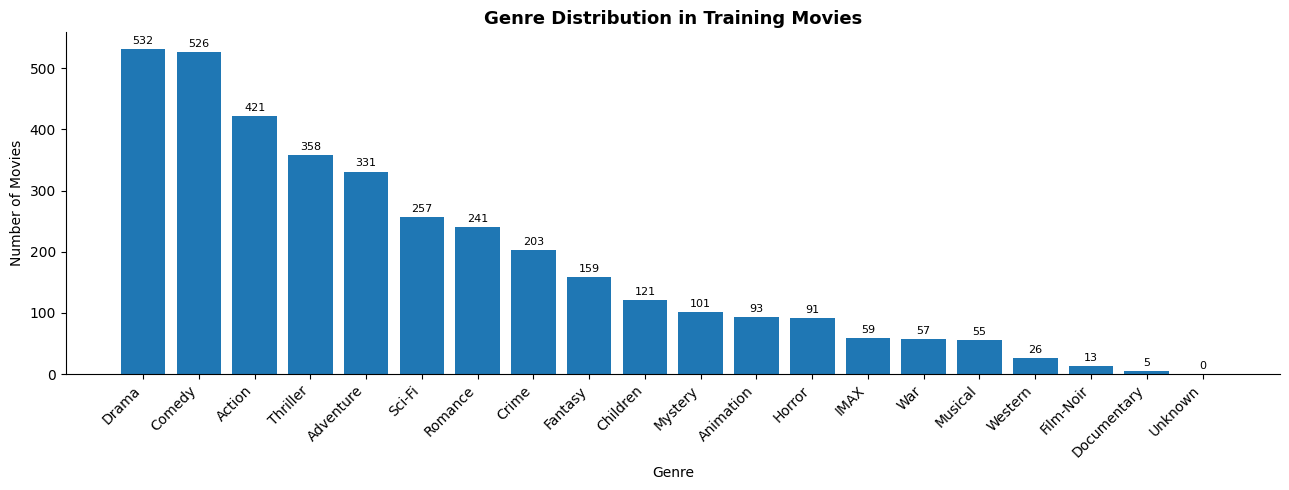

Genre distribution chart saved.


In [65]:
# Visualize Genre Distribution

# Objective:
# Analyze how genres are distributed across training movies.

# Motivation:
# Uneven genre distribution may introduce bias in the model.
# For example, if certain genres dominate the dataset,
# the recommender may favor those genres excessively.

# This visualization helps identify such imbalances and
# interpret recommendation behavior.


# Count number of movies per genre
genre_counts = movies_in_train[genre_feature_cols].sum().sort_values(ascending=False)

# Convert categories to numeric positions
x = range(len(genre_counts))

plt.figure(figsize=(13, 5))

bars = plt.bar(x, genre_counts.values)

plt.title('Genre Distribution in Training Movies',
          fontsize=13, fontweight='bold')

plt.xlabel('Genre')
plt.ylabel('Number of Movies')

# Set genre names as x-axis labels
plt.xticks(x, genre_counts.index, rotation=45, ha='right')

# Annotate bars
for i, val in enumerate(genre_counts.values):
    plt.text(i, val + 5, str(int(val)),
             ha='center', va='bottom', fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Genre distribution chart saved.")

In [66]:
# PART 6 — Non-Graph Models + Final Performance Comparison

# Objective:
# Build and evaluate traditional (non-graph) recommendation
# models and compare their performance against graph-based
# approaches developed earlier.

# Motivation:
# This comparison helps assess the effectiveness of graph-based
# methods relative to classical recommender system techniques.

# NON-GRAPH MODELS:

# Model 1: SVD (Matrix Factorization)
# Decomposes the user-item interaction matrix into latent
# factors. Each user and item is represented by a vector in a
# shared latent space.
# Recommendation score = dot product(user_vector, item_vector).

# Model 2: KNN (User-Based Collaborative Filtering)
# Identifies similar users based on interaction patterns and
# recommends items liked by similar users but not yet seen
# by the target user.

# Model 3: Random Forest Classifier
# Formulates recommendation as a classification task:
# Given a (user, item) pair → predict probability of liking.
# Uses engineered features such as:
#   - User statistics (activity, average rating)
#   - Item statistics (popularity, average rating)

# FINAL EVALUATION:
# All models are evaluated using the same metrics:
#   - Precision@K
#   - Recall@K
#   - NDCG@K

# This ensures a fair and consistent comparison across:
#   - Graph-based models (PPR, GNN, Hybrid)
#   - Non-graph models (SVD, KNN, Random Forest)

In [67]:
# Build User-Item Interaction Matrix

# Objective:
# Construct a user–item matrix required for traditional
# recommendation models such as SVD and KNN.

# Matrix structure:
#   Rows    → users
#   Columns → items (movies)
#   Values  → ratings (0 indicates no interaction)

# Since the matrix is highly sparse (most user–item pairs
# have no interaction), we use a sparse representation
# (CSR format) for memory efficiency and faster computation.

# We also map userId and movieId to contiguous indices
# required for matrix-based algorithms.

from scipy.sparse import csr_matrix

# Map original IDs to continuous integer indices (0 → N-1)
# Required for matrix indexing
all_user_ids  = train_data['userId'].unique()
all_movie_ids = train_data['movieId'].unique()

# Create ID → index mappings
user_to_idx  = {uid: i for i, uid in enumerate(all_user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(all_movie_ids)}

# Reverse mapping (index → movieId) for later decoding
idx_to_movie = {i: mid for mid, i in movie_to_idx.items()}

num_users  = len(all_user_ids)
num_movies = len(all_movie_ids)

# Prepare row indices (users), column indices (movies),
# and corresponding rating values
rows   = train_data['userId'].map(user_to_idx).values
cols   = train_data['movieId'].map(movie_to_idx).values
values = train_data['rating'].values

# Construct sparse user-item matrix in CSR format
user_item_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(num_users, num_movies)
)

print(f" User-Item sparse matrix built.")
print(f"   Shape   : {user_item_matrix.shape}")
print(f"   Density : "
      f"{user_item_matrix.nnz / (num_users * num_movies) * 100:.2f}%")
print(f"   Non-zero: {user_item_matrix.nnz} ratings")

 User-Item sparse matrix built.
   Shape   : (385, 1296)
   Density : 6.51%
   Non-zero: 32500 ratings


In [68]:
# NON-GRAPH MODEL 1 — SVD (Matrix Factorization)

In [69]:
# Train SVD (Matrix Factorization) Model

# Objective:
# Train a matrix factorization model (SVD) to learn latent
# representations of users and movies.

# Idea:
# The user–item matrix is decomposed into two lower-dimensional
# matrices:
#   - User latent factors
#   - Item latent factors

# Each user and movie is represented as a vector in a shared
# latent space, where similarity reflects preference.

# Prediction:
#   rating(u, m) ≈ dot(user_vector, movie_vector)

# Training:
# The model learns these vectors by minimizing the error between
# predicted and actual ratings using gradient descent.

from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split

# Use Surprise library for efficient SVD implementation
# ratings must be in range [rating_scale]
reader       = Reader(rating_scale=(0.5, 5.0))
surprise_data = Dataset.load_from_df(
    train_data[['userId', 'movieId', 'rating']],
    reader
)

# Build full training set (no internal split)
trainset = surprise_data.build_full_trainset()

# SVD HYPERPARAMETERS:
#   n_factors  : number of latent features per user/item
#   n_epochs   : number of training iterations
#   lr_all     : learning rate
#   reg_all    : regularization strength (prevents overfitting)
svd_model = SVD(
    n_factors = 100,
    n_epochs  = 20,
    lr_all    = 0.005,
    reg_all   = 0.02,
    random_state = 42
)
svd_model.fit(trainset)

print(" SVD model trained.")
print(f"   Latent factors : 100")
print(f"   Epochs         : 20")

 SVD model trained.
   Latent factors : 100
   Epochs         : 20


In [70]:
# Generate Recommendations using SVD

# Objective:
# Use the trained SVD model to generate top-K recommendations
# for each user and evaluate performance.

# Approach:
#   1. Identify movies already seen by the user (training set)
#   2. Predict ratings for unseen movies using SVD
#   3. Rank movies by predicted rating
#   4. Select top-K as recommendations

# Note:
# Previously seen items are excluded to ensure realistic
# recommendation scenarios.


# Number of recommendations per user
K = 10

# Store evaluation metrics across users
svd_precision_scores = []
svd_recall_scores    = []
svd_ndcg_scores      = []
svd_all_recs         = {}

print(f"Generating SVD recommendations for "
      f"{len(test_users_in_graph)} users...")

for i, uid in enumerate(test_users_in_graph):

    # Retrieve movies already interacted with in training
    seen = set(train_data[
        train_data['userId'] == uid
    ]['movieId'].values)

    # Identify candidate movies not yet seen by the user
    unseen_movies = [mid for mid in all_movie_ids
                     if mid not in seen]

    # Predict user preference score for each unseen movie
    predictions = [
        (mid, svd_model.predict(uid, mid).est)
        for mid in unseen_movies
    ]

    # Rank movies by predicted rating (highest first)
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_k = [mid for mid, _ in predictions[:K]]

    svd_all_recs[uid] = top_k

    # Retrieve ground truth interactions (test set)
    actual = ground_truth.get(uid, [])
    if not actual:
        continue

    svd_precision_scores.append(precision_at_k(top_k, actual, K))
    svd_recall_scores.append(recall_at_k(top_k, actual, K))
    svd_ndcg_scores.append(ndcg_at_k(top_k, actual, K))

    # Compute evaluation metrics for this user
    if (i + 1) % 50 == 0 or (i + 1) == len(test_users_in_graph):
        print(f"  Processed {i+1}/{len(test_users_in_graph)} users...")

# Compute average performance across users
avg_svd_precision = np.mean(svd_precision_scores)
avg_svd_recall    = np.mean(svd_recall_scores)
avg_svd_ndcg      = np.mean(svd_ndcg_scores)

print("\n" + "=" * 45)
print(f"  SVD (Matrix Factorization) — @K={K}")

print(f"  Precision@{K} : {avg_svd_precision:.4f}")
print(f"  Recall@{K}    : {avg_svd_recall:.4f}")
print(f"  NDCG@{K}      : {avg_svd_ndcg:.4f}")

svd_results = {
    'model'     : 'SVD (Matrix Factorization)',
    'precision' : avg_svd_precision,
    'recall'    : avg_svd_recall,
    'ndcg'      : avg_svd_ndcg
}

Generating SVD recommendations for 385 users...
  Processed 50/385 users...
  Processed 100/385 users...
  Processed 150/385 users...
  Processed 200/385 users...
  Processed 250/385 users...
  Processed 300/385 users...
  Processed 350/385 users...
  Processed 385/385 users...

  SVD (Matrix Factorization) — @K=10
  Precision@10 : 0.0623
  Recall@10    : 0.0369
  NDCG@10      : 0.0693


In [71]:
# NON-GRAPH MODEL 2 — KNN (User-Based Collaborative Filter)

In [72]:
# Train KNN (User-Based Collaborative Filtering)

# Objective:
# Build a user-based collaborative filtering model using KNN.

# Idea:
# Identify users with similar rating patterns and recommend
# items liked by similar users.

# Approach:
# - Represent each user as a vector of ratings
# - Compute similarity between users using cosine similarity
# - Retrieve top-K nearest neighbors for each user

# Note:
# KNN is a memory-based method — it does not learn parameters.
# Instead, it stores the interaction matrix and computes
# similarities at query time.

knn_model = NearestNeighbors(
    metric    = 'cosine',
    algorithm = 'brute',   # brute-force exact search
    n_neighbors = 20       # find top 20 similar users
)

knn_model.fit(user_item_matrix)

print(" KNN model fitted.")
print(f"   Metric     : cosine similarity")
print(f"   Neighbours : 20")
print(f"   Matrix     : {user_item_matrix.shape}")

 KNN model fitted.
   Metric     : cosine similarity
   Neighbours : 20
   Matrix     : (385, 1296)


In [73]:
# Generate Recommendations using KNN

# Objective:
# Generate top-K recommendations using user-based
# collaborative filtering (KNN).

# Approach:
#   1. Identify nearest neighbors (similar users)
#   2. Aggregate their preferences to score candidate items
#   3. Exclude items already seen by the target user
#   4. Rank items by aggregated score and select top-K

# Scoring:
# Each movie is scored based on weighted contributions
# from similar users:
#   score = sum(similarity × rating)

# Note:
# The target user is excluded from neighbors to avoid
# trivial self-matching.


# Number of recommendations per user
K = 10

# Store evaluation metrics across users
knn_precision_scores = []
knn_recall_scores    = []
knn_ndcg_scores      = []
knn_all_recs         = {}

print(f"Generating KNN recommendations for "
      f"{len(test_users_in_graph)} users...")

for i, uid in enumerate(test_users_in_graph):

    if uid not in user_to_idx:
        continue

    u_idx = user_to_idx[uid]

    # Retrieve user's interaction vector from the matrix
    user_vector = user_item_matrix[u_idx]

    # Find nearest neighbors (including self, which will be removed)
    distances, indices = knn_model.kneighbors(
        user_vector, n_neighbors=21   # +1 because user matches itself
    )

    # Convert cosine distance to similarity score
    # (similarity = 1 - distance)
    similarities = 1 - distances.flatten()
    neighbour_indices = indices.flatten()

    # Identify movies already seen by the user
    seen = set(train_data[
        train_data['userId'] == uid
    ]['movieId'].values)

    # Aggregate weighted scores from similar users
    # Score = sum(similarity × rating) across neighbors
    movie_scores = {}

    for sim, n_idx in zip(similarities[1:], neighbour_indices[1:]):
        if sim <= 0:
            continue
        # Get movies this neighbour rated (non-zero entries)
        neighbour_row   = user_item_matrix[n_idx]
        rated_movie_idx = neighbour_row.nonzero()[1]

        for m_idx in rated_movie_idx:
            mid = idx_to_movie[m_idx]
            if mid not in seen:
                rating = neighbour_row[0, m_idx]
                # Weight = similarity × rating
                movie_scores[mid] = movie_scores.get(mid, 0) + sim * rating

    # Rank movies by aggregated score (highest first)
    top_k = sorted(movie_scores, key=movie_scores.get, reverse=True)[:K]
    knn_all_recs[uid] = top_k

    actual = ground_truth.get(uid, [])
    if not actual:
        continue

    knn_precision_scores.append(precision_at_k(top_k, actual, K))
    knn_recall_scores.append(recall_at_k(top_k, actual, K))
    knn_ndcg_scores.append(ndcg_at_k(top_k, actual, K))

    if (i + 1) % 50 == 0 or (i + 1) == len(test_users_in_graph):
        print(f"  Processed {i+1}/{len(test_users_in_graph)} users...")

avg_knn_precision = np.mean(knn_precision_scores)
avg_knn_recall    = np.mean(knn_recall_scores)
avg_knn_ndcg      = np.mean(knn_ndcg_scores)

print("\n" + "=" * 45)
print(f"   KNN (User-Based) — @K={K}")

print(f"  Precision@{K} : {avg_knn_precision:.4f}")
print(f"  Recall@{K}    : {avg_knn_recall:.4f}")
print(f"  NDCG@{K}      : {avg_knn_ndcg:.4f}")

knn_results = {
    'model'     : 'KNN (User-Based)',
    'precision' : avg_knn_precision,
    'recall'    : avg_knn_recall,
    'ndcg'      : avg_knn_ndcg
}

Generating KNN recommendations for 385 users...
  Processed 50/385 users...
  Processed 100/385 users...
  Processed 150/385 users...
  Processed 200/385 users...
  Processed 250/385 users...
  Processed 300/385 users...
  Processed 350/385 users...
  Processed 385/385 users...

   KNN (User-Based) — @K=10
  Precision@10 : 0.2379
  Recall@10    : 0.1457
  NDCG@10      : 0.2812


In [74]:
# NON-GRAPH MODEL 3 — Random Forest Classifier

In [75]:
# Feature Engineering for Random Forest

# Objective:
# Construct numerical features for each (user, movie) pair
# to enable supervised learning using a Random Forest model.

# Approach:
# We engineer three types of features:
#   1. User-level statistics (user behavior)
#   2. Movie-level statistics (item characteristics)
#   3. Interaction feature (user vs item relationship)

# Target:
#   liked = 1 if user liked the movie, else 0

# These features allow the model to learn patterns such as:
#   - Whether the user tends to give high ratings
#   - Whether the movie is generally well received
#   - Whether the user rates above/below average


# Compute aggregate statistics per user
user_stats = train_data.groupby('userId')['rating'].agg(
    user_mean_rating = 'mean',
    user_num_ratings = 'count',
    user_rating_std  = 'std'
).fillna(0).reset_index()

# Compute aggregate statistics per movie
movie_stats = train_data.groupby('movieId')['rating'].agg(
    movie_mean_rating = 'mean',
    movie_num_ratings = 'count',
    movie_rating_std  = 'std'
).fillna(0).reset_index()

# Merge user and movie features into training dataset
rf_train = train_data.merge(user_stats,  on='userId',  how='left')
rf_train = rf_train.merge(movie_stats, on='movieId', how='left')

rf_train['liked'] = (rf_train['rating'] >= 4.5).astype(int)

# Compute interaction feature (user bias vs movie average)
rf_train['rating_diff'] = (
    rf_train['user_mean_rating'] - rf_train['movie_mean_rating']
)

# Define feature set for model input
FEATURE_COLS = [
    'user_mean_rating',  'user_num_ratings',  'user_rating_std',
    'movie_mean_rating', 'movie_num_ratings', 'movie_rating_std',
    'rating_diff'
]

# Input features (X) and target labels (y)
X_train = rf_train[FEATURE_COLS].values
y_train = rf_train['liked'].values

print(f" Features built.")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Feature columns  : {FEATURE_COLS}")

 Features built.
   Training samples : 32500
   Feature columns  : ['user_mean_rating', 'user_num_ratings', 'user_rating_std', 'movie_mean_rating', 'movie_num_ratings', 'movie_rating_std', 'rating_diff']


In [76]:
# Train Random Forest Classifier

# Objective:
# Train a supervised learning model to predict whether a user
# will like a movie based on engineered features.

# Problem formulation:
# Binary classification:
#   liked = 1 → user is likely to enjoy the movie
#   liked = 0 → user is unlikely to enjoy the movie

# Model:
# Random Forest is an ensemble of decision trees that improves
# prediction accuracy by combining multiple models.

# Prediction:
# We use predict_proba() to estimate the probability that a
# user will like a movie, which is used for ranking items.

rf_model = RandomForestClassifier(
    n_estimators = 100,    # Number of decision trees in the ensemble
    max_depth    = 10,     # Limit tree depth to reduce overfitting
    random_state = 42,
    n_jobs       = -1      # Use all available CPU cores for faster training
)

# Train model on feature matrix
rf_model.fit(X_train, y_train)

print(" Random Forest trained.")
print(f"   Trees      : 100")
print(f"   Max depth  : 10")

# Analyze feature importance (model interpretability)
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print(f"\n Feature Importances:")
for feat, imp in importances.items():
    bar = '█' * int(imp * 50)
    print(f"  {feat:<22} {bar} {imp:.4f}")

 Random Forest trained.
   Trees      : 100
   Max depth  : 10

 Feature Importances:
  user_mean_rating       ██████████████ 0.2803
  movie_mean_rating      ██████████ 0.2169
  rating_diff            ██████ 0.1302
  user_rating_std        ██████ 0.1210
  movie_rating_std       ██████ 0.1207
  movie_num_ratings      ███ 0.0749
  user_num_ratings       ██ 0.0559


In [77]:
print(rf_train['liked'].value_counts())

liked
0    20553
1    11947
Name: count, dtype: int64


In [78]:
# Generate Recommendations using Random Forest

# Objective:
# Generate top-K recommendations using the trained Random Forest model.

# Approach:
#   1. Construct feature vectors for (user, unseen movie) pairs
#   2. Predict probability of user liking each movie
#   3. Rank movies by predicted probability
#   4. Select top-K as recommendations

# Note:
# Feature construction is required at inference time since
# Random Forest operates on explicit numerical features.


# Number of recommendations per user
K = 10

# Store evaluation metrics across users
rf_precision_scores = []
rf_recall_scores    = []
rf_ndcg_scores      = []
rf_all_recs         = {}

# Precompute lookup dictionaries for efficient feature construction
movie_stats_dict = movie_stats.set_index('movieId').to_dict('index')
user_stats_dict  = user_stats.set_index('userId').to_dict('index')

print(f"Generating Random Forest recommendations for "
      f"{len(test_users_in_graph)} users...")

for i, uid in enumerate(test_users_in_graph):
    # Skip users without computed statistics
    if uid not in user_stats_dict:
        continue

    u_stats = user_stats_dict[uid]
    # Skip users without computed statistics
    seen    = set(train_data[
        train_data['userId'] == uid
    ]['movieId'].values)

    # Candidate movies not yet seen by the user
    unseen = [mid for mid in all_movie_ids if mid not in seen]

    if not unseen:
        continue

    # Build feature vectors for each (user, movie) pair
    feature_rows = []
    valid_unseen = []

    for mid in unseen:
      # Combine user stats + movie stats + interaction feature
        if mid not in movie_stats_dict:
            continue
        m_stats = movie_stats_dict[mid]
        feature_rows.append([
            u_stats['user_mean_rating'],
            u_stats['user_num_ratings'],
            u_stats['user_rating_std'],
            m_stats['movie_mean_rating'],
            m_stats['movie_num_ratings'],
            m_stats['movie_rating_std'],
            u_stats['user_mean_rating'] - m_stats['movie_mean_rating']
        ])
        valid_unseen.append(mid)

    if not feature_rows:
        continue

    # Convert feature list to NumPy array for model input
    X_unseen = np.array(feature_rows)

    # Predict probability that user will like each movie
    proba    = rf_model.predict_proba(X_unseen)[:, 1]

    # Rank movies by predicted probability (highest first)
    top_idx  = np.argsort(proba)[::-1][:K]
    top_k    = [valid_unseen[j] for j in top_idx]

    rf_all_recs[uid] = top_k

    actual = ground_truth.get(uid, [])
    if not actual:
        continue

    rf_precision_scores.append(precision_at_k(top_k, actual, K))
    rf_recall_scores.append(recall_at_k(top_k, actual, K))
    rf_ndcg_scores.append(ndcg_at_k(top_k, actual, K))

    if (i + 1) % 50 == 0 or (i + 1) == len(test_users_in_graph):
        print(f"  Processed {i+1}/{len(test_users_in_graph)} users...")

avg_rf_precision = np.mean(rf_precision_scores)
avg_rf_recall    = np.mean(rf_recall_scores)
avg_rf_ndcg      = np.mean(rf_ndcg_scores)

print("\n" + "=" * 45)
print(f"  Random Forest — @K={K}")
print("=" * 45)
print(f"  Precision@{K} : {avg_rf_precision:.4f}")
print(f"  Recall@{K}    : {avg_rf_recall:.4f}")
print(f"  NDCG@{K}      : {avg_rf_ndcg:.4f}")
print("=" * 45)

rf_results = {
    'model'     : 'Random Forest',
    'precision' : avg_rf_precision,
    'recall'    : avg_rf_recall,
    'ndcg'      : avg_rf_ndcg
}

Generating Random Forest recommendations for 385 users...
  Processed 50/385 users...
  Processed 100/385 users...
  Processed 150/385 users...
  Processed 200/385 users...
  Processed 250/385 users...
  Processed 300/385 users...
  Processed 350/385 users...
  Processed 385/385 users...

  Random Forest — @K=10
  Precision@10 : 0.0688
  Recall@10    : 0.0368
  NDCG@10      : 0.0869


In [79]:
# FINAL COMPARISON — All Models Side by Side

In [80]:
# Objective:
# Compare all recommendation models using standard metrics
# to identify the best-performing approach.

# Metrics:
#   - Precision@K : accuracy of recommendations
#   - Recall@K    : coverage of relevant items
#   - NDCG@K      : ranking quality (higher = better ordering)

# Note:
# Models are ranked by NDCG since it accounts for both
# relevance and position of recommendations.

# Aggregate results from all models into a single table
all_results = pd.DataFrame([
    ppr_results,
    gnn_results,
    cb_results,
    hybrid_results,
    svd_results,
    knn_results,
    rf_results
])

# Rank models by NDCG (primary metric)
all_results = all_results.sort_values('ndcg', ascending=False)
all_results = all_results.reset_index(drop=True)
all_results.index += 1   # rank starts at 1

# Format metrics for readable output
display_df = all_results.copy()
for col in ['precision', 'recall', 'ndcg']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")


print(f"  FINAL MODEL COMPARISON — Precision / Recall / NDCG @K={K}")
print(display_df[['model','precision','recall','ndcg']].to_string())

  FINAL MODEL COMPARISON — Precision / Recall / NDCG @K=10
                        model precision  recall    ndcg
1            KNN (User-Based)    0.2379  0.1457  0.2812
2              GNN (LightGCN)    0.1953  0.1148  0.2241
3               Random Forest    0.0688  0.0368  0.0869
4  SVD (Matrix Factorization)    0.0623  0.0369  0.0693
5               Content-Based    0.0408  0.0247  0.0426
6      Hybrid (PPR + Content)    0.0358  0.0217  0.0397
7                   Graph PPR    0.0327  0.0133  0.0315


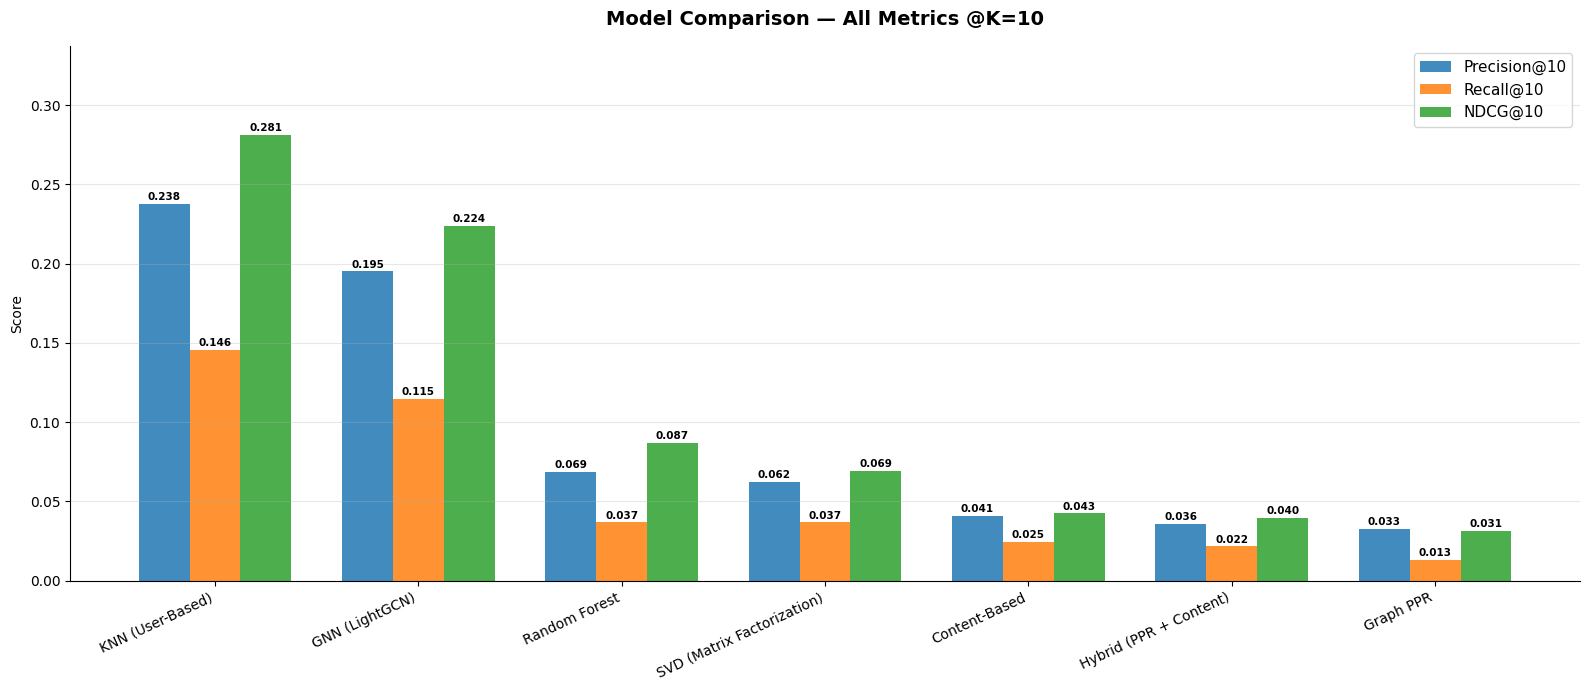

Comparison chart saved.


In [81]:
# Visual Comparison of Models

# Objective:
# Visually compare all models across evaluation metrics.

# This grouped bar chart allows us to:
#   - Compare Precision, Recall, and NDCG side by side
#   - Identify strengths and weaknesses of each model
#   - Easily spot the best-performing model

# Use numeric values (NOT formatted strings)
models     = all_results['model'].tolist()
precisions = all_results['precision'].astype(float).tolist()
recalls    = all_results['recall'].astype(float).tolist()
ndcgs      = all_results['ndcg'].astype(float).tolist()

x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - width, precisions, width,
               label=f'Precision@{K}', alpha=0.85)

bars2 = ax.bar(x, recalls, width,
               label=f'Recall@{K}', alpha=0.85)

bars3 = ax.bar(x + width, ndcgs, width,
               label=f'NDCG@{K}', alpha=0.85)

# Annotate bar heights
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.001, f'{h:.3f}',
                ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_title(f'Model Comparison — All Metrics @K={K}',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(recalls), max(ndcgs)) * 1.2)
ax.grid(axis='y', alpha=0.3)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")

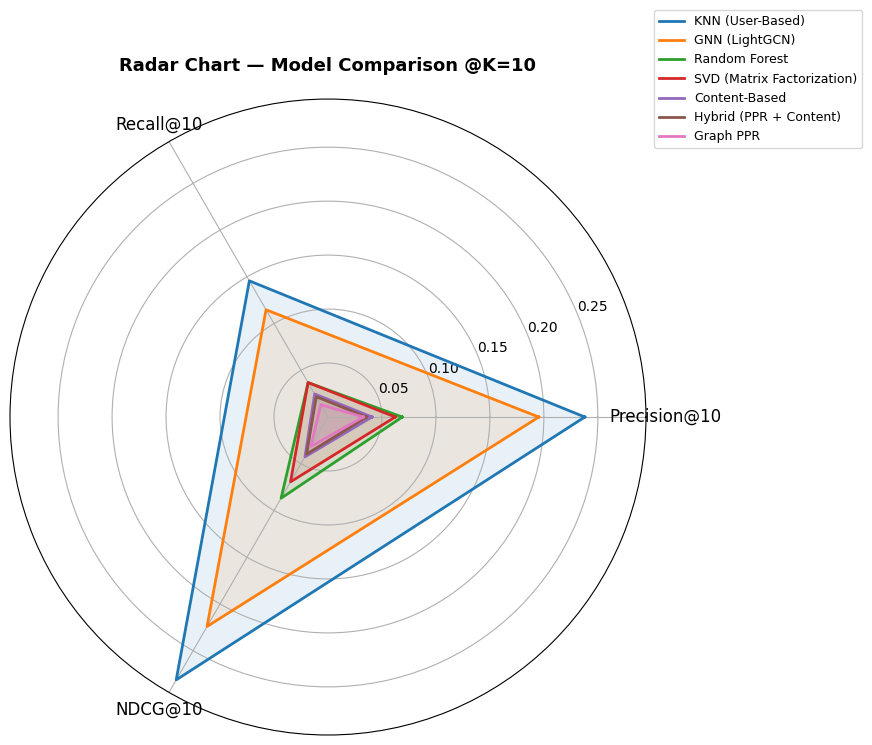

Radar chart saved.


In [82]:
# Radar Chart (Multi-Metric Comparison)

# Objective:
# Provide a holistic visual comparison of all models across
# multiple evaluation metrics simultaneously.

# Why Radar Chart?
# Unlike bar charts (which compare metrics separately),
# a radar chart displays all metrics in a single view,
# making it easier to assess overall model balance.

# Interpretation:
#   - Each axis represents a metric (Precision, Recall, NDCG)
#   - Each polygon represents a model
#   - Larger area → better overall performance
#   - More symmetrical shape → more balanced model

# Insight:
# This visualization helps identify models that not only
# perform well but also maintain consistency across metrics.

categories  = [f'Precision@{K}', f'Recall@{K}', f'NDCG@{K}']
N           = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9),
                       subplot_kw=dict(polar=True))

for _, row in all_results.iterrows():
    values_radar  = [row['precision'], row['recall'], row['ndcg']]
    values_radar += values_radar[:1]

    ax.plot(angles, values_radar,
            linewidth=2, label=row['model'])

    ax.fill(angles, values_radar,
            alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

ax.set_title(f'Radar Chart — Model Comparison @K={K}',
             fontsize=13, fontweight='bold', pad=20)

ax.legend(loc='upper right',
          bbox_to_anchor=(1.35, 1.15),
          fontsize=9)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Radar chart saved.")

In [85]:
# Final Summary

best_model  = all_results.iloc[0]
worst_model = all_results.iloc[-1]
second_model = all_results.iloc[1]

print(f"""
   Best Model  : {best_model['model']}
   Precision@{K} = {best_model['precision']:.4f}
   Recall@{K}    = {best_model['recall']:.4f}
   NDCG@{K}      = {best_model['ndcg']:.4f}

   Second Best : {second_model['model']}
   Precision@{K} = {second_model['precision']:.4f}
   Recall@{K}    = {second_model['recall']:.4f}
   NDCG@{K}      = {second_model['ndcg']:.4f}

   Worst Model : {worst_model['model']}
   Precision@{K} = {worst_model['precision']:.4f}
   Recall@{K}    = {worst_model['recall']:.4f}
   NDCG@{K}      = {worst_model['ndcg']:.4f}

      """)


   Best Model  : KNN (User-Based)
   Precision@10 = 0.2379
   Recall@10    = 0.1457
   NDCG@10      = 0.2812

   Second Best : GNN (LightGCN)
   Precision@10 = 0.1953
   Recall@10    = 0.1148
   NDCG@10      = 0.2241

   Worst Model : Graph PPR
   Precision@10 = 0.0327
   Recall@10    = 0.0133
   NDCG@10      = 0.0315

      


In [86]:
print(f"""
Insights:
   • {best_model['model']} achieved the highest NDCG@{K} of
     {best_model['ndcg']:.4f}, outperforming all other models.

   • KNN performed best due to high user similarity density
     in the dataset — neighbourhood methods excel when many
     users share overlapping rating histories.

   • GNN (LightGCN) ranked 2nd, confirming that learned
     graph embeddings capture meaningful structural patterns
     even when they do not beat neighbourhood methods.

   • Graph PPR ranked last because it is a hand-crafted
     algorithm with no learning component. It relies purely
     on graph structure without adapting to the data.

   • Hybrid and Content-Based models ranked low, suggesting
     genre features add limited signal beyond what rating
     patterns already provide in this dataset.

💡 Key Takeaway:
   Model performance is dataset-dependent. KNN outperforms
   graph-based models here because MovieLens is dense enough
   for strong user-user similarities to exist. Graph-based
   methods are more valuable on sparse datasets where
   multi-hop connections carry more information.
""")

print("=" * 60)
print("Project complete!")


Insights:
   • KNN (User-Based) achieved the highest NDCG@10 of
     0.2812, outperforming all other models.

   • KNN performed best due to high user similarity density
     in the dataset — neighbourhood methods excel when many
     users share overlapping rating histories.

   • GNN (LightGCN) ranked 2nd, confirming that learned
     graph embeddings capture meaningful structural patterns
     even when they do not beat neighbourhood methods.

   • Graph PPR ranked last because it is a hand-crafted
     algorithm with no learning component. It relies purely
     on graph structure without adapting to the data.

   • Hybrid and Content-Based models ranked low, suggesting
     genre features add limited signal beyond what rating
     patterns already provide in this dataset.

💡 Key Takeaway:
   Model performance is dataset-dependent. KNN outperforms
   graph-based models here because MovieLens is dense enough
   for strong user-user similarities to exist. Graph-based
   methods are m